In [87]:
# ============================================================
# CÉLULA 1 — CONFIGURAÇÃO GERAL DO PROJETO
# ============================================================
#
# PROJETO:
# Modelagem das emissões horárias de CO2 de unidade
# termelétrica utilizando dados CEMS da EPA.
#
# OBJETIVO DESTA CÉLULA:
#
#   1. montar o Google Drive;
#   2. definir a pasta raiz do projeto;
#   3. criar uma estrutura compatível com futuro repositório
#      GitHub;
#   4. configurar a API da EPA;
#   5. disponibilizar diretórios e funções utilizados nas
#      demais etapas do notebook.
#
# ============================================================


# ============================================================
# 1. IMPORTAÇÕES
# ============================================================

from google.colab import drive, userdata
from pathlib import Path

import pandas as pd
import numpy as np

import requests
import json
import re
import time
import zipfile

import xml.etree.ElementTree as ET


# ============================================================
# 2. MONTAR O GOOGLE DRIVE
# ============================================================

drive.mount("/content/drive")


# ============================================================
# 3. PASTA RAIZ DO PROJETO
# ============================================================
#
# Esta pasta corresponde à futura raiz do repositório GitHub.
#
# Estrutura esperada:
#
# co2-cems-thermal-modeling/
#
#   notebooks/
#   data/
#       raw/
#       interim/
#       processed/
#   outputs/
#       reports/
#       figures/
#       tables/
#   pipeline/
#
# ============================================================

ROOT = Path(
    "/content/drive/MyDrive/co2-cems-thermal-modeling"
)


# ============================================================
# 4. DIRETÓRIOS DE DADOS
# ============================================================

DATA = ROOT / "data"

DATA_RAW = (
    DATA
    / "raw"
)

DATA_INTERIM = (
    DATA
    / "interim"
)

DATA_PROCESSED = (
    DATA
    / "processed"
)


# ============================================================
# 5. DIRETÓRIOS DE RESULTADOS
# ============================================================
#
# Mantemos a variável OUTPUT porque ela já é utilizada nas
# etapas anteriores do notebook.
# ============================================================

OUTPUT = ROOT / "outputs"

REPORTS = (
    OUTPUT
    / "reports"
)

FIGURES = (
    OUTPUT
    / "figures"
)

TABLES = (
    OUTPUT
    / "tables"
)


# ============================================================
# 6. DIRETÓRIO DE INTERFACE ENTRE NOTEBOOKS
# ============================================================
#
# O diretório pipeline contém os arquivos que fazem a ligação
# entre as diferentes fases do projeto.
#
# Exemplo:
#
# Notebook 1
# Seleção da unidade
#
#       ↓
#
# selected_unit.json
# selected_unit_hourly_raw.parquet
#
#       ↓
#
# Notebook 2
# Tratamento dos dados
#
# ============================================================

PIPELINE_DIR = (
    ROOT
    / "pipeline"
)


# ============================================================
# 7. DIRETÓRIO DOS NOTEBOOKS
# ============================================================

NOTEBOOKS = (
    ROOT
    / "notebooks"
)


# ============================================================
# 8. CRIAÇÃO AUTOMÁTICA DAS PASTAS
# ============================================================

PROJECT_FOLDERS = [

    ROOT,

    NOTEBOOKS,

    DATA,
    DATA_RAW,
    DATA_INTERIM,
    DATA_PROCESSED,

    OUTPUT,
    REPORTS,
    FIGURES,
    TABLES,

    PIPELINE_DIR
]


for folder in PROJECT_FOLDERS:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# 9. DIRETÓRIO TEMPORÁRIO DO COLAB
# ============================================================
#
# Downloads grandes e temporários da EPA ficam no armazenamento
# local do Colab.
#
# Esses arquivos não precisam ser preservados no Drive nem
# enviados posteriormente ao GitHub.
# ============================================================

TEMP = Path(
    "/content/epa_temp"
)

TEMP.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 10. CHAVE DA API DA EPA
# ============================================================
#
# A chave deve estar armazenada nos Secrets do Google Colab
# com o nome:
#
#       EPA_API_KEY
#
# Nunca escrever a chave diretamente no notebook.
# ============================================================

EPA_API_KEY = (
    userdata
    .get("EPA_API_KEY")
    .strip()
)


# ============================================================
# 11. SESSÃO HTTP
# ============================================================

session = requests.Session()

session.headers.update({

    "User-Agent":
        "co2-cems-thermal-modeling"

})


# ============================================================
# 12. FUNÇÃO PADRÃO PARA CONSULTAS À EPA
# ============================================================

def epa_get(
    url,
    params=None,
    timeout=120
):

    params = (
        {}
        if params is None
        else dict(params)
    )

    params["api_key"] = (
        EPA_API_KEY
    )


    response = session.get(
        url,
        params=params,
        timeout=timeout
    )


    if response.status_code != 200:

        print(
            "STATUS:",
            response.status_code
        )

        print(
            response.text[:1000]
        )


    response.raise_for_status()

    return response


# ============================================================
# 13. ENDPOINTS PRINCIPAIS DA EPA
# ============================================================

CATALOG_URL = (
    "https://api.epa.gov/easey/camd-services/bulk-files"
)

BULK_URL = (
    "https://api.epa.gov/easey/bulk-files/"
)

FACILITY_URL = (
    "https://api.epa.gov/easey/facilities-mgmt/"
    "facilities/attributes"
)


# ============================================================
# 14. PARÂMETROS GERAIS DO ESTUDO
# ============================================================

YEAR = 2025


# ============================================================
# 15. VERIFICAÇÃO DA CONFIGURAÇÃO
# ============================================================

print("=" * 70)
print("PROJETO CONFIGURADO")
print("=" * 70)


print(
    "\nPasta raiz:"
)

print(
    ROOT
)


print(
    "\nEstrutura de dados:"
)

print(
    "RAW       →",
    DATA_RAW
)

print(
    "INTERIM   →",
    DATA_INTERIM
)

print(
    "PROCESSED →",
    DATA_PROCESSED
)


print(
    "\nResultados:"
)

print(
    "REPORTS →",
    REPORTS
)

print(
    "FIGURES →",
    FIGURES
)

print(
    "TABLES  →",
    TABLES
)


print(
    "\nPipeline:"
)

print(
    PIPELINE_DIR
)


print(
    "\nNotebooks:"
)

print(
    NOTEBOOKS
)


print(
    "\nTemporários:"
)

print(
    TEMP
)


print(
    "\nAno de análise:",
    YEAR
)


print(
    "Chave EPA carregada:",
    bool(EPA_API_KEY)
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJETO CONFIGURADO

Pasta raiz:
/content/drive/MyDrive/co2-cems-thermal-modeling

Estrutura de dados:
RAW       → /content/drive/MyDrive/co2-cems-thermal-modeling/data/raw
INTERIM   → /content/drive/MyDrive/co2-cems-thermal-modeling/data/interim
PROCESSED → /content/drive/MyDrive/co2-cems-thermal-modeling/data/processed

Resultados:
REPORTS → /content/drive/MyDrive/co2-cems-thermal-modeling/outputs/reports
FIGURES → /content/drive/MyDrive/co2-cems-thermal-modeling/outputs/figures
TABLES  → /content/drive/MyDrive/co2-cems-thermal-modeling/outputs/tables

Pipeline:
/content/drive/MyDrive/co2-cems-thermal-modeling/pipeline

Notebooks:
/content/drive/MyDrive/co2-cems-thermal-modeling/notebooks

Temporários:
/content/epa_temp

Ano de análise: 2025
Chave EPA carregada: True


In [47]:
# ============================================================
# ETAPA 1 — CATÁLOGO EPA
# ============================================================

CATALOG_URL = (
    "https://api.epa.gov/easey/"
    "camd-services/bulk-files"
)

response = epa_get(
    CATALOG_URL,
    timeout=120
)

catalog = pd.json_normalize(
    response.json()["items"]
)

print(
    "Total de arquivos:",
    f"{len(catalog):,}"
)

display(
    catalog[
        ["metadata.dataType", "metadata.dataSubType"]
    ]
    .value_counts()
    .reset_index(name="arquivos")
)

Total de arquivos: 235,457


,metadata.dataType,metadata.dataSubType,arquivos
0,XML,Emissions,95230
1,XML,QA,79308
2,XML,Monitoring Plan,1710
3,Emissions,Hourly,1610
4,Emissions,Daily,1601
5,Mercury and Air Toxics Emissions (MATS),Daily,434
6,Mercury and Air Toxics Emissions (MATS),Hourly,46


In [48]:
# ============================================================
# ETAPA 2 — UNIDADES EPA EM 2025
# ============================================================

FACILITIES_URL = (
    "https://api.epa.gov/easey/"
    "facilities-mgmt/facilities/attributes"
)


def get_population(year):

    registros = []
    page = 1

    while True:

        # IMPORTANTE:
        # usamos epa_get(), não session.get()
        r = epa_get(
            FACILITIES_URL,
            params={
                "year": year,
                "page": page,
                "perPage": 500
            },
            timeout=120
        )

        data = r.json()
        items = data.get("items", [])

        if not items:
            break

        registros.extend(items)

        print(
            f"Página {page}: "
            f"{len(items)} registros"
        )

        if len(items) < 500:
            break

        page += 1

    return pd.DataFrame(registros)


# ------------------------------------------------------------
# Buscar população de 2025
# ------------------------------------------------------------

population_2025 = get_population(YEAR)


# ------------------------------------------------------------
# Normalizar identificadores
# ------------------------------------------------------------

population_2025["facilityId"] = (
    population_2025["facilityId"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.strip()
)

population_2025["unitId"] = (
    population_2025["unitId"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.strip()
)


print("\nRESULTADO")
print("-" * 50)

print(
    "Registros unidade-ano:",
    f"{len(population_2025):,}"
)

print(
    "Unidades físicas:",
    population_2025[
        ["facilityId", "unitId"]
    ]
    .drop_duplicates()
    .shape[0]
)


# ------------------------------------------------------------
# Visualizar colunas importantes
# ------------------------------------------------------------

cols = [
    "stateCode",
    "facilityName",
    "facilityId",
    "unitId",
    "primaryFuelInfo",
    "secondaryFuelInfo",
    "unitType",
    "operatingStatus",
    "associatedGeneratorsAndNameplateCapacity"
]

cols_existentes = [
    c for c in cols
    if c in population_2025.columns
]

display(
    population_2025[
        cols_existentes
    ].head(20)
)

Página 1: 500 registros
Página 2: 500 registros
Página 3: 500 registros
Página 4: 500 registros
Página 5: 500 registros
Página 6: 500 registros
Página 7: 500 registros
Página 8: 500 registros
Página 9: 57 registros

RESULTADO
--------------------------------------------------
Registros unidade-ano: 4,057
Unidades físicas: 4057


,stateCode,facilityName,facilityId,unitId,primaryFuelInfo,secondaryFuelInfo,unitType,operatingStatus,associatedGeneratorsAndNameplateCapacity
0,AL,Barry,3,1,Pipeline Natural Gas,None,Tangentially-fired,Operating,1 (153)
1,AL,Barry,3,2,Pipeline Natural Gas,None,Tangentially-fired,Operating,2 (153)
2,AL,Barry,3,4,Pipeline Natural Gas,None,Tangentially-fired,Operating,4 (403)
3,AL,Barry,3,5,Coal,Pipeline Natural Gas,Tangentially-fired,Operating,5 (788)
4,AL,Barry,3,6A,Pipeline Natural Gas,None,Combined cycle,Operating,"A1ST (191.8), A1CT (170.1)"
5,AL,Barry,3,6B,Pipeline Natural Gas,None,Combined cycle,Operating,"A1CT2 (170.1), A1ST (191.8)"
6,AL,Barry,3,7A,Pipeline Natural Gas,None,Combined cycle,Operating,"A2ST (191.8), A2C1 (170.1)"
7,AL,Barry,3,7B,Pipeline Natural Gas,None,Combined cycle,Operating,"A2ST (191.8), A2C2 (170.1)"
8,AL,Barry,3,8,Pipeline Natural Gas,None,Combined cycle,Operating,"A3C1 (457), A3ST (305.1)"
9,TX,Copper Station,9,CTG-1,Pipeline Natural Gas,None,Combustion turbine,Operating,1 (70)


In [49]:
# ============================================================
# ETAPA 3 — CANDIDATAS: CARVÃO + GERAÇÃO A VAPOR
# ============================================================

df = population_2025.copy()


# ------------------------------------------------------------
# 1. Combustível principal a carvão
# ------------------------------------------------------------

coal_pattern = (
    r"coal|bituminous|subbituminous|"
    r"anthracite|lignite"
)

is_coal = (
    df["primaryFuelInfo"]
    .astype(str)
    .str.contains(
        coal_pattern,
        case=False,
        na=False,
        regex=True
    )
)


# ------------------------------------------------------------
# 2. Tipo de unidade compatível com caldeira / coal steam
# ------------------------------------------------------------
#
# Não estamos dizendo que unitType = "Rankine".
#
# Estamos eliminando explicitamente tecnologias incompatíveis,
# como turbinas a gás, motores e combined cycle.
# ------------------------------------------------------------

not_steam_boiler = (
    df["unitType"]
    .astype(str)
    .str.contains(
        r"combined cycle|combustion turbine|"
        r"internal combustion|engine|kiln|"
        r"process heater|other turbine",
        case=False,
        na=False,
        regex=True
    )
)

is_boiler = ~not_steam_boiler


# ------------------------------------------------------------
# 3. Gerador elétrico associado
# ------------------------------------------------------------

if "associatedGeneratorsAndNameplateCapacity" in df.columns:

    has_generator = (
        df["associatedGeneratorsAndNameplateCapacity"]
        .notna()
    )

else:

    # Não excluir se a coluna não vier da API
    has_generator = pd.Series(
        True,
        index=df.index
    )


candidates_meta = (
    df[
        is_coal
        &
        is_boiler
        &
        has_generator
    ]
    .copy()
    .drop_duplicates(
        subset=["facilityId", "unitId"]
    )
    .reset_index(drop=True)
)


print(
    "Candidatas após carvão + boiler:",
    len(candidates_meta)
)

display(
    candidates_meta[
        [
            c for c in [
                "stateCode",
                "facilityName",
                "facilityId",
                "unitId",
                "primaryFuelInfo",
                "unitType",
                "operatingStatus",
                "associatedGeneratorsAndNameplateCapacity"
            ]
            if c in candidates_meta.columns
        ]
    ]
)

Candidatas após carvão + boiler: 421


,stateCode,facilityName,facilityId,unitId,primaryFuelInfo,unitType,operatingStatus,associatedGeneratorsAndNameplateCapacity
0,AL,Barry,3,5,Coal,Tangentially-fired,Operating,5 (788)
1,AL,E C Gaston,26,5,Coal,Tangentially-fired,Operating,5 (952)
2,NE,Platte,59,1,Coal,Tangentially-fired,Operating,1 (109)
3,NE,Gerald Whelan Energy Center,60,1,Coal,Tangentially-fired,Operating,1 (77)
4,NE,Gerald Whelan Energy Center,60,2,Coal,Dry bottom wall-fired boiler,Operating,2 (220)
...,...,...,...,...,...,...,...,...
416,ND,Spiritwood Station,56786,001,Coal,Circulating fluidized bed boiler,Operating,1 (99)
417,VA,Virginia City Hybrid Energy Center,56808,1,Coal,Circulating fluidized bed boiler,Operating,1 (668)
418,VA,Virginia City Hybrid Energy Center,56808,2,Coal,Circulating fluidized bed boiler,Operating,1 (668)
419,PR,"AES Puerto Rico, LP",880102,1,Coal,Circulating fluidized bed boiler,Operating,1 (260)


In [50]:
# ============================================================
# ETAPA 4 — MONITORING PLANS DAS CANDIDATAS
# Versão robusta para Facility ID
# ============================================================

monitoring_plans = (
    catalog[
        (catalog["metadata.dataType"] == "XML")
        &
        (catalog["metadata.dataSubType"] == "Monitoring Plan")
    ]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 1. Normalizar Facility ID das candidatas
# ------------------------------------------------------------

candidates_meta = candidates_meta.copy()

candidates_meta["facilityId_num"] = pd.to_numeric(
    candidates_meta["facilityId"],
    errors="coerce"
).astype("Int64")


# ------------------------------------------------------------
# 2. Extrair Facility ID do nome do Monitoring Plan
#
# Exemplo:
# 003149_MP.zip -> 3149
# ------------------------------------------------------------

monitoring_plans["facilityId_num"] = pd.to_numeric(
    monitoring_plans["filename"]
    .astype(str)
    .str.extract(r"^(\d+)", expand=False),
    errors="coerce"
).astype("Int64")


# ------------------------------------------------------------
# 3. Auditoria ANTES do cruzamento
# ------------------------------------------------------------

candidate_facilities = set(
    candidates_meta["facilityId_num"]
    .dropna()
    .astype(int)
)

mp_facilities = set(
    monitoring_plans["facilityId_num"]
    .dropna()
    .astype(int)
)

overlap = (
    candidate_facilities
    &
    mp_facilities
)


print("=" * 60)
print("AUDITORIA DOS FACILITY IDs")
print("=" * 60)

print(
    "Unidades candidatas:",
    len(candidates_meta)
)

print(
    "Facilities candidatas únicas:",
    len(candidate_facilities)
)

print(
    "Monitoring Plans no catálogo:",
    len(monitoring_plans)
)

print(
    "Facilities com Monitoring Plan:",
    len(mp_facilities)
)

print(
    "Facilities em comum:",
    len(overlap)
)


print("\nExemplos de Facility IDs das candidatas:")
print(
    sorted(candidate_facilities)[:20]
)

print("\nExemplos de Facility IDs dos Monitoring Plans:")
print(
    sorted(mp_facilities)[:20]
)


# ------------------------------------------------------------
# 4. Selecionar Monitoring Plans das candidatas
# ------------------------------------------------------------

mp_candidates = (
    monitoring_plans[
        monitoring_plans["facilityId_num"].isin(
            overlap
        )
    ]
    .copy()
    .reset_index(drop=True)
)


# Padronizar facilityId para as próximas etapas
mp_candidates["facilityId"] = (
    mp_candidates["facilityId_num"]
    .astype(str)
)


print("\n" + "=" * 60)
print("RESULTADO")
print("=" * 60)

print(
    "Monitoring Plans selecionados:",
    len(mp_candidates)
)

print(
    "Facilities selecionadas:",
    mp_candidates["facilityId_num"].nunique()
)


display(
    mp_candidates[
        [
            "facilityId",
            "filename",
            "metadata.stateCode",
            "s3Path"
        ]
    ].head(20)
)

AUDITORIA DOS FACILITY IDs
Unidades candidatas: 421
Facilities candidatas únicas: 202
Monitoring Plans no catálogo: 1710
Facilities com Monitoring Plan: 1710
Facilities em comum: 202

Exemplos de Facility IDs das candidatas:
[3, 26, 59, 60, 108, 113, 127, 130, 136, 160, 165, 298, 470, 525, 564, 594, 602, 628, 667, 703]

Exemplos de Facility IDs dos Monitoring Plans:
[3, 7, 8, 9, 10, 26, 47, 50, 51, 54, 56, 59, 60, 87, 108, 113, 116, 117, 118, 120]

RESULTADO
Monitoring Plans selecionados: 202
Facilities selecionadas: 202


,facilityId,filename,metadata.stateCode,s3Path
0,56671,056671_MP.zip,WV,xml/mp/056671_MP.zip
1,127,000127_MP.zip,TX,xml/mp/000127_MP.zip
2,59,000059_MP.zip,NE,xml/mp/000059_MP.zip
3,113,000113_MP.zip,AZ,xml/mp/000113_MP.zip
4,108,000108_MP.zip,KS,xml/mp/000108_MP.zip
5,3,000003_MP.zip,AL,xml/mp/000003_MP.zip
6,60,000060_MP.zip,NE,xml/mp/000060_MP.zip
7,26,000026_MP.zip,AL,xml/mp/000026_MP.zip
8,1012,001012_MP.zip,IN,xml/mp/001012_MP.zip
9,160,000160_MP.zip,AZ,xml/mp/000160_MP.zip


In [51]:
# ============================================================
# ETAPA 5 — DOWNLOAD DOS MONITORING PLANS NECESSÁRIOS
# ============================================================

MP_DIR = DATA / "monitoring_plans_candidates"
MP_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BULK_URL = (
    "https://api.epa.gov/easey/bulk-files/"
)


for i, row in enumerate(
    mp_candidates.itertuples(index=False),
    start=1
):

    destino = (
        MP_DIR
        /
        row.filename
    )

    if destino.exists():
        continue

    url = (
        BULK_URL
        +
        str(row.s3Path).lstrip("/")
    )

    for tentativa in range(1, 6):

        try:

            r = session.get(
                url,
                timeout=180
            )

            r.raise_for_status()

            destino.write_bytes(
                r.content
            )

            print(
                f"[{i}/{len(mp_candidates)}] "
                f"{row.filename} ✓"
            )

            break

        except requests.RequestException as e:

            if tentativa == 5:
                raise

            espera = tentativa * 15

            print(
                f"Falha em {row.filename}. "
                f"Nova tentativa em {espera}s."
            )

            time.sleep(espera)

In [59]:
# ============================================================
# ETAPA 6 — IDENTIFICAR CO2-CEM NA UNIDADE CORRETA
# ============================================================

import re
import zipfile
import pandas as pd
import xml.etree.ElementTree as ET


def tag_name(tag):
    """
    Remove o namespace XML.
    """
    return tag.split("}")[-1]


def get_text(element, field):
    """
    Obtém o conteúdo de um filho direto do elemento.
    """
    for child in element:
        if tag_name(child.tag) == field:
            return child.text

    return None


def normalize_unit_scalar(value):

    if value is None:
        return None

    value = str(value).strip().upper()

    value = re.sub(
        r"\.0$",
        "",
        value
    )

    if re.fullmatch(r"\d+", value):
        value = str(int(value))

    return value


registros = []

locations_total = 0
unit_locations = 0
co2_methods_total = 0
co2_cem_total = 0


# ============================================================
# PROCESSAR CADA MONITORING PLAN
# ============================================================

for i, filename in enumerate(
    mp_candidates["filename"],
    start=1
):

    arquivo = MP_DIR / filename

    # --------------------------------------------------------
    # Facility ID
    #
    # 003149_MP.zip -> 3149
    # --------------------------------------------------------

    facility_id = str(
        int(
            str(filename)
            .split("_")[0]
        )
    )


    with zipfile.ZipFile(
        arquivo,
        "r"
    ) as z:

        for xml_name in z.namelist():

            if not xml_name.lower().endswith(".xml"):
                continue


            root = ET.fromstring(
                z.read(xml_name)
            )


            # =================================================
            # IMPORTANTE:
            #
            # Percorrer TODAS as MonitoringLocationData
            # individualmente.
            # =================================================

            for location in root.iter():

                if (
                    tag_name(location.tag)
                    != "MonitoringLocationData"
                ):
                    continue


                locations_total += 1


                # ---------------------------------------------
                # Identificação desta localização
                # ---------------------------------------------

                unit_id = get_text(
                    location,
                    "UnitID"
                )

                stack_pipe_id = get_text(
                    location,
                    "StackPipeID"
                )


                # ---------------------------------------------
                # Queremos somente localização de UNIT
                #
                # Ignorar stacks/pipes.
                # ---------------------------------------------

                if unit_id is None:
                    continue

                if stack_pipe_id is not None:
                    continue


                unit_locations += 1

                unit_id_norm = normalize_unit_scalar(
                    unit_id
                )


                # =============================================
                # Procurar métodos SOMENTE DENTRO DESTA
                # MonitoringLocationData
                #
                # Não usar root.iter() aqui.
                # =============================================

                for element in location.iter():

                    if (
                        tag_name(element.tag)
                        != "MonitoringMethodData"
                    ):
                        continue


                    parameter = get_text(
                        element,
                        "ParameterCode"
                    )

                    method = get_text(
                        element,
                        "MonitoringMethodCode"
                    )


                    # -----------------------------------------
                    # Qualquer método de CO2
                    # -----------------------------------------

                    if parameter == "CO2":

                        co2_methods_total += 1


                    # -----------------------------------------
                    # Nosso critério:
                    #
                    # CO2 + CEM
                    # -----------------------------------------

                    if not (
                        parameter == "CO2"
                        and
                        method == "CEM"
                    ):
                        continue


                    co2_cem_total += 1


                    registros.append({

                        "facilityId":
                            facility_id,

                        "unitId":
                            str(unit_id).strip(),

                        "unitId_norm":
                            unit_id_norm,

                        "parameter":
                            parameter,

                        "method":
                            method,

                        "beginDate":
                            get_text(
                                element,
                                "BeginDate"
                            ),

                        "beginHour":
                            get_text(
                                element,
                                "BeginHour"
                            ),

                        "endDate":
                            get_text(
                                element,
                                "EndDate"
                            ),

                        "endHour":
                            get_text(
                                element,
                                "EndHour"
                            )
                    })


    if i % 50 == 0:

        print(
            f"{i}/{len(mp_candidates)} "
            "Monitoring Plans processados"
        )


# ============================================================
# CONSTRUIR DATAFRAME
# ============================================================

co2_cem = pd.DataFrame(
    registros
)


if len(co2_cem) > 0:

    co2_cem = (
        co2_cem
        .drop_duplicates()
        .reset_index(drop=True)
    )


    co2_cem["beginDate"] = pd.to_datetime(
        co2_cem["beginDate"],
        errors="coerce"
    )


    co2_cem["endDate"] = pd.to_datetime(
        co2_cem["endDate"],
        errors="coerce"
    )


# ============================================================
# RESULTADOS
# ============================================================

print("\n" + "=" * 60)
print("RESULTADO DA ETAPA 6")
print("=" * 60)

print(
    "MonitoringLocationData analisadas:",
    f"{locations_total:,}"
)

print(
    "Localizações diretamente em UNIT:",
    f"{unit_locations:,}"
)

print(
    "Métodos de CO2 encontrados:",
    f"{co2_methods_total:,}"
)

print(
    "Registros CO2-CEM:",
    f"{co2_cem_total:,}"
)


if len(co2_cem) > 0:

    print(
        "Unidades únicas com CO2-CEM:",
        co2_cem[
            [
                "facilityId",
                "unitId_norm"
            ]
        ]
        .drop_duplicates()
        .shape[0]
    )


    display(
        co2_cem.head(20)
    )

50/202 Monitoring Plans processados
100/202 Monitoring Plans processados
150/202 Monitoring Plans processados
200/202 Monitoring Plans processados

RESULTADO DA ETAPA 6
MonitoringLocationData analisadas: 1,040
Localizações diretamente em UNIT: 843
Métodos de CO2 encontrados: 627
Registros CO2-CEM: 526
Unidades únicas com CO2-CEM: 380


,facilityId,unitId,unitId_norm,parameter,method,beginDate,beginHour,endDate,endHour
0,56671,001,1,CO2,CEM,2011-10-01,23,NaT,None
1,127,1,1,CO2,CEM,1995-01-01,0,NaT,None
2,59,1,1,CO2,CEM,1995-01-26,0,NaT,None
3,113,2,2,CO2,CEM,1995-01-01,0,NaT,None
4,113,4,4,CO2,CEM,1995-01-01,0,NaT,None
5,113,1,1,CO2,CEM,1995-01-01,7,NaT,None
6,113,3,3,CO2,CEM,1995-01-01,0,NaT,None
7,108,SGU1,SGU1,CO2,CEM,1995-01-01,0,NaT,None
8,3,5,5,CO2,CEM,2008-03-29,0,2009-12-31,23
9,3,4,4,CO2,CEM,2014-10-01,0,NaT,None


In [60]:
# ============================================================
# ETAPA 7 — CEMS VÁLIDO AO LONGO DE 2025
# ============================================================

YEAR_START = pd.Timestamp(
    "2025-01-01"
)

YEAR_END = pd.Timestamp(
    "2025-12-31"
)


cem_2025 = (
    co2_cem[
        (co2_cem["beginDate"] <= YEAR_START)
        &
        (
            co2_cem["endDate"].isna()
            |
            (co2_cem["endDate"] >= YEAR_END)
        )
    ]
    [
        ["facilityId", "unitId"]
    ]
    .drop_duplicates()
)


candidates = (
    candidates_meta
    .merge(
        cem_2025.assign(
            co2_cem_2025=True
        ),
        on=[
            "facilityId",
            "unitId"
        ],
        how="inner"
    )
    .reset_index(drop=True)
)


print(
    "Candidatas carvão + boiler + CO2-CEM em 2025:",
    len(candidates)
)

display(
    candidates[
        [
            c for c in [
                "stateCode",
                "facilityName",
                "facilityId",
                "unitId",
                "primaryFuelInfo",
                "unitType",
                "operatingStatus"
            ]
            if c in candidates.columns
        ]
    ]
)

Candidatas carvão + boiler + CO2-CEM em 2025: 303


,stateCode,facilityName,facilityId,unitId,primaryFuelInfo,unitType,operatingStatus
0,AL,Barry,3,5,Coal,Tangentially-fired,Operating
1,NE,Platte,59,1,Coal,Tangentially-fired,Operating
2,NE,Gerald Whelan Energy Center,60,1,Coal,Tangentially-fired,Operating
3,NE,Gerald Whelan Energy Center,60,2,Coal,Dry bottom wall-fired boiler,Operating
4,KS,Holcomb,108,SGU1,Coal,Dry bottom wall-fired boiler,Operating
...,...,...,...,...,...,...,...
298,TX,Sandy Creek Energy Station,56611,S01,Coal,Dry bottom wall-fired boiler,Operating
299,WV,Longview Power,56671,001,Coal,Dry bottom wall-fired boiler,Operating
300,ND,Spiritwood Station,56786,001,Coal,Circulating fluidized bed boiler,Operating
301,VA,Virginia City Hybrid Energy Center,56808,1,Coal,Circulating fluidized bed boiler,Operating


In [61]:
# ============================================================
# DIAGNÓSTICO DA ETAPA 7
# ============================================================


print("candidates_meta:", len(candidates_meta))
print("mp_candidates:", len(mp_candidates))
print("co2_cem:", len(co2_cem))
print("cem_2025:", len(cem_2025))
print("candidates finais:", len(candidates))

candidates_meta: 421
mp_candidates: 202
co2_cem: 394
cem_2025: 348
candidates finais: 303


In [62]:
# ============================================================
# ETAPA 8 — ARQUIVOS HORÁRIOS 2025
# ============================================================

hourly_catalog = (
    catalog[
        (catalog["metadata.dataType"] == "Emissions")
        &
        (catalog["metadata.dataSubType"] == "Hourly")
    ]
    .copy()
)


hourly_catalog["year"] = pd.to_numeric(
    hourly_catalog["metadata.year"],
    errors="coerce"
)

hourly_catalog["stateCode"] = (
    hourly_catalog["metadata.stateCode"]
    .astype(str)
    .str.upper()
    .str.strip()
)


states_needed = (
    candidates["stateCode"]
    .dropna()
    .astype(str)
    .str.upper()
    .unique()
)


hourly_files_2025 = (
    hourly_catalog[
        (hourly_catalog["year"] == YEAR)
        &
        (hourly_catalog["stateCode"].isin(
            states_needed
        ))
    ]
    .copy()
)


print(
    "Estados necessários:",
    len(states_needed)
)

print(
    "Arquivos horários necessários:",
    len(hourly_files_2025)
)

display(
    hourly_files_2025[
        [
            "stateCode",
            "filename",
            "s3Path"
        ]
    ]
)

Estados necessários: 38
Arquivos horários necessários: 38


,stateCode,filename,s3Path
235234,AK,emissions-hourly-2025-ak.csv,emissions/hourly/state/emissions-hourly-2025-a...
235238,AL,emissions-hourly-2025-al.csv,emissions/hourly/state/emissions-hourly-2025-a...
235240,AZ,emissions-hourly-2025-az.csv,emissions/hourly/state/emissions-hourly-2025-a...
235244,AR,emissions-hourly-2025-ar.csv,emissions/hourly/state/emissions-hourly-2025-a...
235249,DE,emissions-hourly-2025-de.csv,emissions/hourly/state/emissions-hourly-2025-d...
235251,CO,emissions-hourly-2025-co.csv,emissions/hourly/state/emissions-hourly-2025-c...
235260,IN,emissions-hourly-2025-in.csv,emissions/hourly/state/emissions-hourly-2025-i...
235262,IL,emissions-hourly-2025-il.csv,emissions/hourly/state/emissions-hourly-2025-i...
235264,KY,emissions-hourly-2025-ky.csv,emissions/hourly/state/emissions-hourly-2025-k...
235270,KS,emissions-hourly-2025-ks.csv,emissions/hourly/state/emissions-hourly-2025-k...


In [64]:
print("candidates_meta:", len(candidates_meta))
print("mp_candidates:", len(mp_candidates))
print("co2_cem:", len(co2_cem))
print("cem_2025:", len(cem_2025))
print("candidates finais:", len(candidates))

candidates_meta: 421
mp_candidates: 202
co2_cem: 394
cem_2025: 348
candidates finais: 303


In [70]:
# ============================================================
# ETAPA 9 — EXTRAÇÃO HORÁRIA DAS UNIDADES CANDIDATAS
# ============================================================

import re
import time
import pandas as pd


# ------------------------------------------------------------
# CONFIGURAÇÕES LOCAIS
# ------------------------------------------------------------

BULK_URL = "https://api.epa.gov/easey/bulk-files/"

selected_chunks = []


# ------------------------------------------------------------
# FUNÇÕES DE NORMALIZAÇÃO
# ------------------------------------------------------------

def norm_facility_id(x):
    """
    Normaliza Facility ID.

    Exemplos:
        3149      -> "3149"
        3149.0    -> "3149"
        "003149"  -> "3149"
    """

    if pd.isna(x):
        return None

    try:
        return str(int(float(x)))

    except (ValueError, TypeError):
        return str(x).strip()


def norm_unit_id(x):
    """
    Normaliza Unit ID preservando IDs alfanuméricos.

    Exemplos:
        1       -> "1"
        1.0     -> "1"
        "001"   -> "1"
        "SGU1"  -> "SGU1"
        " LIM1 " -> "LIM1"
    """

    if pd.isna(x):
        return None

    x = str(x).strip().upper()

    # Remove ".0" caso tenha surgido na leitura
    x = re.sub(r"\.0$", "", x)

    # Se for puramente numérico, remove zeros à esquerda
    if re.fullmatch(r"\d+", x):
        x = str(int(x))

    return x


# ============================================================
# 1. PREPARAR AS 303 CANDIDATAS
# ============================================================

candidates_9 = candidates.copy()


candidates_9["facilityId_norm"] = (
    candidates_9["facilityId"]
    .apply(norm_facility_id)
)


candidates_9["unitId_norm"] = (
    candidates_9["unitId"]
    .apply(norm_unit_id)
)


candidates_9["stateCode"] = (
    candidates_9["stateCode"]
    .astype(str)
    .str.upper()
    .str.strip()
)


print("=" * 60)
print("PREPARAÇÃO DAS CANDIDATAS")
print("=" * 60)

print(
    "Candidatas recebidas:",
    len(candidates_9)
)

print(
    "Unidades únicas:",
    candidates_9[
        ["facilityId_norm", "unitId_norm"]
    ]
    .drop_duplicates()
    .shape[0]
)


# ============================================================
# 2. CRIAR CHAVES FACILITY + UNIT POR ESTADO
# ============================================================

candidate_keys_by_state = {}


for state, group in candidates_9.groupby("stateCode"):

    keys = set(
        group["facilityId_norm"].astype(str)
        + "|"
        + group["unitId_norm"].astype(str)
    )

    candidate_keys_by_state[state] = keys


print(
    "Estados com candidatas:",
    len(candidate_keys_by_state)
)


# ============================================================
# 3. NORMALIZAR TABELA DOS ARQUIVOS HORÁRIOS
# ============================================================

hourly_files_9 = hourly_files_2025.copy()


hourly_files_9["stateCode"] = (
    hourly_files_9["stateCode"]
    .astype(str)
    .str.upper()
    .str.strip()
)


print(
    "Arquivos horários a processar:",
    len(hourly_files_9)
)


# ============================================================
# 4. COLUNAS QUE VAMOS EXTRAIR
# ============================================================

required_columns = [
    "Facility ID",
    "Unit ID",
    "Date",
    "Hour",
    "Operating Time",
    "Gross Load (MW)",
    "CO2 Mass (short tons)"
]


optional_columns = [
    "CO2 Mass Measure Indicator"
]


# ============================================================
# 5. PROCESSAR CADA ESTADO
# ============================================================

total_matched = 0
states_with_matches = 0


for i, row in enumerate(
    hourly_files_9.itertuples(index=False),
    start=1
):

    state = str(row.stateCode).upper().strip()
    filename = str(row.filename)

    s3_path = str(row.s3Path).lstrip("/")

    url = BULK_URL + s3_path

    tmp = TEMP / filename


    print("\n" + "-" * 60)

    print(
        f"[{i}/{len(hourly_files_9)}] "
        f"{state} — {filename}"
    )


    # --------------------------------------------------------
    # DOWNLOAD COM ATÉ 3 TENTATIVAS
    # --------------------------------------------------------

    download_ok = False


    for tentativa in range(1, 4):

        try:

            with session.get(
                url,
                params={
                    "api_key": EPA_API_KEY
                },
                stream=True,
                timeout=(30, 300)
            ) as r:

                print(
                    f"Download — tentativa {tentativa}: "
                    f"HTTP {r.status_code}"
                )

                r.raise_for_status()


                with open(tmp, "wb") as f:

                    for block in r.iter_content(
                        chunk_size=1024 * 1024
                    ):

                        if block:
                            f.write(block)


            download_ok = True
            break


        except Exception as e:

            print(
                "Falha no download:",
                str(e)
            )

            if tentativa < 3:
                time.sleep(10)


    if not download_ok:

        raise RuntimeError(
            f"Não foi possível baixar {filename}."
        )


    print(
        "Tamanho:",
        round(
            tmp.stat().st_size
            / 1024
            / 1024,
            2
        ),
        "MB"
    )


    # --------------------------------------------------------
    # VERIFICAR CABEÇALHO
    # --------------------------------------------------------

    header = pd.read_csv(
        tmp,
        nrows=0
    )


    available_columns = set(
        header.columns
    )


    missing_columns = [
        c
        for c in required_columns
        if c not in available_columns
    ]


    if missing_columns:

        raise ValueError(
            f"\nArquivo {filename} não contém "
            f"as colunas obrigatórias:\n"
            f"{missing_columns}\n\n"
            f"Colunas disponíveis:\n"
            f"{list(header.columns)}"
        )


    usecols = required_columns.copy()


    for col in optional_columns:

        if col in available_columns:
            usecols.append(col)


    # --------------------------------------------------------
    # PROCESSAR CSV EM PARTES
    # --------------------------------------------------------

    matched_rows_state = 0


    for chunk in pd.read_csv(
        tmp,
        usecols=usecols,
        chunksize=250_000,
        low_memory=False
    ):


        # ---------------------------------------------
        # Normalizar Facility ID
        # ---------------------------------------------

        chunk["facilityId_norm"] = (
            chunk["Facility ID"]
            .apply(norm_facility_id)
        )


        # ---------------------------------------------
        # Normalizar Unit ID
        # ---------------------------------------------

        chunk["unitId_norm"] = (
            chunk["Unit ID"]
            .apply(norm_unit_id)
        )


        # ---------------------------------------------
        # Chave Facility + Unit
        # ---------------------------------------------

        chunk["_key"] = (
            chunk["facilityId_norm"].astype(str)
            + "|"
            + chunk["unitId_norm"].astype(str)
        )


        expected_keys = candidate_keys_by_state.get(
            state,
            set()
        )


        mask = chunk["_key"].isin(
            expected_keys
        )


        selected = (
            chunk.loc[mask]
            .drop(
                columns=["_key"]
            )
            .copy()
        )


        if not selected.empty:

            selected_chunks.append(
                selected
            )

            matched_rows_state += len(
                selected
            )


    # --------------------------------------------------------
    # RESULTADO DO ESTADO
    # --------------------------------------------------------

    print(
        "Linhas das candidatas:",
        f"{matched_rows_state:,}"
    )


    if matched_rows_state > 0:

        states_with_matches += 1
        total_matched += matched_rows_state


    # --------------------------------------------------------
    # APAGAR CSV TEMPORÁRIO
    # --------------------------------------------------------

    if tmp.exists():
        tmp.unlink()


# ============================================================
# 6. VERIFICAR SE ALGO FOI ENCONTRADO
# ============================================================

print("\n" + "=" * 60)
print("FIM DOS ARQUIVOS ESTADUAIS")
print("=" * 60)

print(
    "Estados com registros encontrados:",
    states_with_matches
)

print(
    "Linhas encontradas antes do concat:",
    f"{total_matched:,}"
)


if len(selected_chunks) == 0:

    raise ValueError(
        "Nenhuma linha horária foi encontrada para "
        "as unidades candidatas.\n"
        "O problema está no cruzamento entre "
        "Facility ID / Unit ID e os arquivos horários."
    )


# ============================================================
# 7. JUNTAR TODAS AS UNIDADES
# ============================================================

hourly_candidates = pd.concat(
    selected_chunks,
    ignore_index=True
)


# ============================================================
# 8. CRIAR TIMESTAMP
# ============================================================

hourly_candidates["Date"] = pd.to_datetime(
    hourly_candidates["Date"],
    errors="coerce"
)


hourly_candidates["Hour"] = pd.to_numeric(
    hourly_candidates["Hour"],
    errors="coerce"
)


hourly_candidates["timestamp"] = (
    hourly_candidates["Date"]
    +
    pd.to_timedelta(
        hourly_candidates["Hour"],
        unit="h"
    )
)


# ============================================================
# 9. ORDENAR
# ============================================================

hourly_candidates = (
    hourly_candidates
    .sort_values(
        [
            "facilityId_norm",
            "unitId_norm",
            "timestamp"
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 10. RESULTADOS FINAIS
# ============================================================

n_units = (
    hourly_candidates[
        [
            "facilityId_norm",
            "unitId_norm"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)


print("\n" + "=" * 60)
print("RESULTADO DA ETAPA 9")
print("=" * 60)

print(
    "Registros horários extraídos:",
    f"{len(hourly_candidates):,}"
)

print(
    "Unidades encontradas:",
    n_units
)

print(
    "Das candidatas iniciais:",
    len(candidates_9)
)

print(
    "Período:",
    hourly_candidates["timestamp"].min(),
    "→",
    hourly_candidates["timestamp"].max()
)


# ============================================================
# 11. QUANTIDADE DE REGISTROS POR UNIDADE
# ============================================================

unit_counts = (
    hourly_candidates
    .groupby(
        [
            "facilityId_norm",
            "unitId_norm"
        ]
    )
    .size()
    .reset_index(
        name="registros_horarios"
    )
    .sort_values(
        "registros_horarios",
        ascending=False
    )
)


print("\nPrimeiras unidades:")

display(
    unit_counts.head(20)
)


print("\nPrimeiros registros horários:")

display(
    hourly_candidates.head(20)
)

PREPARAÇÃO DAS CANDIDATAS
Candidatas recebidas: 303
Unidades únicas: 303
Estados com candidatas: 38
Arquivos horários a processar: 38

------------------------------------------------------------
[1/38] AK — emissions-hourly-2025-ak.csv
Download — tentativa 1: HTTP 200
Tamanho: 1.91 MB
Linhas das candidatas: 0

------------------------------------------------------------
[2/38] AL — emissions-hourly-2025-al.csv
Download — tentativa 1: HTTP 200
Tamanho: 183.27 MB
Linhas das candidatas: 43,800

------------------------------------------------------------
[3/38] AZ — emissions-hourly-2025-az.csv
Download — tentativa 1: HTTP 200
Tamanho: 175.5 MB
Linhas das candidatas: 78,840

------------------------------------------------------------
[4/38] AR — emissions-hourly-2025-ar.csv
Download — tentativa 1: HTTP 200
Tamanho: 80.01 MB
Linhas das candidatas: 61,320

------------------------------------------------------------
[5/38] DE — emissions-hourly-2025-de.csv
Download — tentativa 1: HTTP 200

,facilityId_norm,unitId_norm,registros_horarios
298,997,12,8760
0,1001,1,8760
1,1001,2,8760
2,10143,AAB01,8760
3,10343,SG-101,8760
4,10603,31,8760
5,1073,3,8760
6,108,SGU1,8760
7,1082,3,8760
8,1082,4,8760



Primeiros registros horários:


,Facility ID,Unit ID,Date,Hour,Operating Time,Gross Load (MW),CO2 Mass (short tons),CO2 Mass Measure Indicator,facilityId_norm,unitId_norm,timestamp
0,1001,1,2025-01-01,0,0.98,0.0,9.506,Measured,1001,1,2025-01-01 00:00:00
1,1001,1,2025-01-01,1,1.00,0.0,21.400,Measured,1001,1,2025-01-01 01:00:00
2,1001,1,2025-01-01,2,1.00,0.0,26.000,Measured,1001,1,2025-01-01 02:00:00
3,1001,1,2025-01-01,3,1.00,0.0,29.300,Measured,1001,1,2025-01-01 03:00:00
4,1001,1,2025-01-01,4,1.00,0.0,19.800,Measured,1001,1,2025-01-01 04:00:00
5,1001,1,2025-01-01,5,1.00,0.0,21.800,Measured,1001,1,2025-01-01 05:00:00
6,1001,1,2025-01-01,6,1.00,0.0,22.100,Measured,1001,1,2025-01-01 06:00:00
7,1001,1,2025-01-01,7,1.00,10.0,36.700,Measured,1001,1,2025-01-01 07:00:00
8,1001,1,2025-01-01,8,1.00,21.0,44.800,Measured,1001,1,2025-01-01 08:00:00
9,1001,1,2025-01-01,9,1.00,47.0,68.600,Measured,1001,1,2025-01-01 09:00:00


In [79]:
# ============================================================
# ETAPA 10 — QUALIDADE E RIQUEZA OPERACIONAL DAS CANDIDATAS
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 0. VERIFICAÇÃO DOS DADOS DE ENTRADA
# ============================================================

required_hourly_columns = [
    "facilityId_norm",
    "unitId_norm",
    "timestamp",
    "Operating Time",
    "Gross Load (MW)",
    "CO2 Mass (short tons)"
]

missing_columns = [
    col
    for col in required_hourly_columns
    if col not in hourly_candidates.columns
]

if missing_columns:
    raise ValueError(
        "Faltam colunas em hourly_candidates: "
        + str(missing_columns)
    )


print("=" * 65)
print("ETAPA 10 — ANÁLISE DAS UNIDADES CANDIDATAS")
print("=" * 65)

print(
    "Registros horários recebidos:",
    f"{len(hourly_candidates):,}"
)

print(
    "Candidatas recebidas da Etapa 9:",
    len(candidates_9)
)


# ============================================================
# 1. IDENTIFICAR AS CANDIDATAS SEM DADOS HORÁRIOS
# ============================================================

keys_found = (
    hourly_candidates[
        [
            "facilityId_norm",
            "unitId_norm"
        ]
    ]
    .drop_duplicates()
    .copy()
)


missing_candidates = (
    candidates_9
    .merge(
        keys_found.assign(
            found_hourly=True
        ),
        on=[
            "facilityId_norm",
            "unitId_norm"
        ],
        how="left"
    )
)


missing_candidates = (
    missing_candidates[
        missing_candidates["found_hourly"].isna()
    ]
    .copy()
)


print("\n" + "=" * 65)
print("CANDIDATAS SEM DADOS HORÁRIOS EM 2025")
print("=" * 65)

print(
    "Quantidade:",
    len(missing_candidates)
)


missing_display_cols = [
    "stateCode",
    "facilityName",
    "facilityId",
    "unitId",
    "primaryFuelInfo",
    "unitType"
]

missing_display_cols = [
    col
    for col in missing_display_cols
    if col in missing_candidates.columns
]


display(
    missing_candidates[
        missing_display_cols
    ]
)


# ============================================================
# 2. PREPARAR DADOS HORÁRIOS
# ============================================================

hourly_10 = hourly_candidates.copy()


# Garantir tipos numéricos

hourly_10["Operating Time"] = pd.to_numeric(
    hourly_10["Operating Time"],
    errors="coerce"
)

hourly_10["Gross Load (MW)"] = pd.to_numeric(
    hourly_10["Gross Load (MW)"],
    errors="coerce"
)

hourly_10["CO2 Mass (short tons)"] = pd.to_numeric(
    hourly_10["CO2 Mass (short tons)"],
    errors="coerce"
)

hourly_10["timestamp"] = pd.to_datetime(
    hourly_10["timestamp"],
    errors="coerce"
)


# Ordenar corretamente no tempo

hourly_10 = (
    hourly_10
    .sort_values(
        [
            "facilityId_norm",
            "unitId_norm",
            "timestamp"
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 3. ANALISAR CADA UNIDADE
# ============================================================

unit_results = []


grouped = hourly_10.groupby(
    [
        "facilityId_norm",
        "unitId_norm"
    ],
    sort=False
)


total_units = grouped.ngroups


print("\n" + "=" * 65)
print("ANALISANDO AS UNIDADES")
print("=" * 65)

print(
    "Unidades a analisar:",
    total_units
)


for i, ((facility_id, unit_id), g) in enumerate(
    grouped,
    start=1
):

    g = (
        g
        .sort_values("timestamp")
        .reset_index(drop=True)
        .copy()
    )


    # --------------------------------------------------------
    # Séries básicas
    # --------------------------------------------------------

    operating_time = g["Operating Time"]

    load = g["Gross Load (MW)"]

    co2 = g["CO2 Mass (short tons)"]


    # --------------------------------------------------------
    # ESTADO OPERACIONAL
    #
    # Ligada = Operating Time > 0
    #
    # Não usamos carga > 0 porque durante startup pode haver
    # emissão antes de geração líquida significativa.
    # --------------------------------------------------------

    on = (
        operating_time
        .fillna(0)
        .gt(0)
        .astype(bool)
    )


    # Estado da hora anterior
    # sem usar fillna(), portanto sem FutureWarning

    previous_on = (
        on
        .shift(
            periods=1,
            fill_value=False
        )
        .astype(bool)
    )


    # --------------------------------------------------------
    # STARTUP E SHUTDOWN
    # --------------------------------------------------------

    startup = (
        on
        &
        (~previous_on)
    )

    shutdown = (
        (~on)
        &
        previous_on
    )


    startups = int(
        startup.sum()
    )

    shutdowns = int(
        shutdown.sum()
    )

    transitions = (
        startups
        +
        shutdowns
    )


    # --------------------------------------------------------
    # HORAS OPERACIONAIS / DESLIGADAS
    # --------------------------------------------------------

    operating_hours = int(
        on.sum()
    )

    off_hours = int(
        (~on).sum()
    )


    # --------------------------------------------------------
    # DADOS NAS HORAS OPERACIONAIS
    # --------------------------------------------------------

    load_on = (
        load[on]
        .dropna()
    )

    co2_on = (
        co2[on]
    )


    # --------------------------------------------------------
    # COBERTURA DE CO2
    # --------------------------------------------------------

    if operating_hours > 0:

        co2_coverage = float(
            co2_on
            .notna()
            .mean()
        )

        load_coverage = float(
            load[on]
            .notna()
            .mean()
        )

    else:

        co2_coverage = np.nan
        load_coverage = np.nan


    # --------------------------------------------------------
    # PROPORÇÃO DE CO2 EXPLICITAMENTE "MEASURED"
    # --------------------------------------------------------

    if (
        "CO2 Mass Measure Indicator"
        in g.columns
        and operating_hours > 0
    ):

        indicator = (
            g.loc[
                on,
                "CO2 Mass Measure Indicator"
            ]
            .astype(str)
            .str.strip()
            .str.lower()
        )


        measured_share = float(
            indicator
            .str.contains(
                "measured",
                na=False
            )
            .mean()
        )

    else:

        measured_share = np.nan


    # --------------------------------------------------------
    # ESTATÍSTICAS DA CARGA
    # --------------------------------------------------------

    if len(load_on) > 0:

        load_mean = float(
            load_on.mean()
        )

        load_std = float(
            load_on.std()
        )

        load_q05 = float(
            load_on.quantile(0.05)
        )

        load_q25 = float(
            load_on.quantile(0.25)
        )

        load_q50 = float(
            load_on.quantile(0.50)
        )

        load_q75 = float(
            load_on.quantile(0.75)
        )

        load_q95 = float(
            load_on.quantile(0.95)
        )


        load_span = (
            load_q95
            -
            load_q05
        )


        if (
            not np.isnan(load_mean)
            and load_mean != 0
        ):

            load_cv = (
                load_std
                /
                load_mean
            )

        else:

            load_cv = np.nan

    else:

        load_mean = np.nan
        load_std = np.nan

        load_q05 = np.nan
        load_q25 = np.nan
        load_q50 = np.nan
        load_q75 = np.nan
        load_q95 = np.nan

        load_span = np.nan
        load_cv = np.nan


    # --------------------------------------------------------
    # VARIAÇÃO HORÁRIA DE CARGA
    #
    # Ainda NÃO classificamos ramp-up/ramp-down.
    # Apenas observamos Delta P entre horas consecutivas.
    # --------------------------------------------------------

    delta_load = (
        load
        .diff()
    )


    abs_delta_load = (
        delta_load[on]
        .abs()
        .dropna()
    )


    if len(abs_delta_load) > 0:

        abs_delta_mean = float(
            abs_delta_load.mean()
        )

        abs_delta_q95 = float(
            abs_delta_load.quantile(0.95)
        )

        abs_delta_max = float(
            abs_delta_load.max()
        )

    else:

        abs_delta_mean = np.nan
        abs_delta_q95 = np.nan
        abs_delta_max = np.nan


    # --------------------------------------------------------
    # MESES COM OPERAÇÃO
    # --------------------------------------------------------

    if operating_hours > 0:

        operating_months = int(
            g.loc[
                on,
                "timestamp"
            ]
            .dt.month
            .nunique()
        )

    else:

        operating_months = 0


    # --------------------------------------------------------
    # ADICIONAR RESULTADO DA UNIDADE
    # --------------------------------------------------------

    unit_results.append({

        "facilityId_norm":
            facility_id,

        "unitId_norm":
            unit_id,

        "rows_2025":
            len(g),

        "operating_hours":
            operating_hours,

        "off_hours":
            off_hours,

        "operating_months":
            operating_months,

        "co2_coverage_operating":
            co2_coverage,

        "load_coverage_operating":
            load_coverage,

        "measured_share_operating":
            measured_share,

        "startups":
            startups,

        "shutdowns":
            shutdowns,

        "transitions":
            transitions,

        "load_mean_mw":
            load_mean,

        "load_std_mw":
            load_std,

        "load_q05_mw":
            load_q05,

        "load_q25_mw":
            load_q25,

        "load_median_mw":
            load_q50,

        "load_q75_mw":
            load_q75,

        "load_q95_mw":
            load_q95,

        "load_span_q05_q95_mw":
            load_span,

        "load_cv":
            load_cv,

        "abs_delta_load_mean_mw":
            abs_delta_mean,

        "abs_delta_load_q95_mw":
            abs_delta_q95,

        "abs_delta_load_max_mw":
            abs_delta_max
    })


    # Mostrar progresso sem poluir a saída

    if (
        i % 50 == 0
        or i == total_units
    ):

        print(
            f"{i}/{total_units} unidades analisadas"
        )


# ============================================================
# 4. CRIAR DATAFRAME DE QUALIDADE
# ============================================================

unit_quality = pd.DataFrame(
    unit_results
)


print("\n" + "=" * 65)
print("ANÁLISE DAS UNIDADES")
print("=" * 65)

print(
    "Unidades analisadas:",
    len(unit_quality)
)


# ============================================================
# 5. ADICIONAR METADADOS DAS USINAS
# ============================================================

metadata_cols = [
    "facilityId_norm",
    "unitId_norm",
    "stateCode",
    "facilityName",
    "primaryFuelInfo",
    "unitType",
    "operatingStatus"
]


metadata_cols = [
    col
    for col in metadata_cols
    if col in candidates_9.columns
]


metadata_units = (
    candidates_9[
        metadata_cols
    ]
    .drop_duplicates(
        subset=[
            "facilityId_norm",
            "unitId_norm"
        ]
    )
    .copy()
)


unit_quality = (
    unit_quality
    .merge(
        metadata_units,
        on=[
            "facilityId_norm",
            "unitId_norm"
        ],
        how="left"
    )
)


# ============================================================
# 6. CRITÉRIOS DE QUALIDADE
# ============================================================

MIN_CO2_COVERAGE = 0.99

MIN_LOAD_COVERAGE = 0.99

MIN_MEASURED_SHARE = 0.95


unit_quality["quality_ok"] = (

    (
        unit_quality["rows_2025"]
        == 8760
    )

    &

    (
        unit_quality[
            "co2_coverage_operating"
        ]
        >= MIN_CO2_COVERAGE
    )

    &

    (
        unit_quality[
            "load_coverage_operating"
        ]
        >= MIN_LOAD_COVERAGE
    )

    &

    (
        unit_quality[
            "measured_share_operating"
        ]
        >= MIN_MEASURED_SHARE
    )

    &

    (
        unit_quality[
            "operating_months"
        ]
        == 12
    )
)


quality_candidates = (
    unit_quality[
        unit_quality["quality_ok"]
    ]
    .copy()
)


print(
    "Unidades que atendem aos critérios de qualidade:",
    len(quality_candidates)
)


# ============================================================
# 7. RANKING EXPLORATÓRIO
#
# Não criamos score artificial.
#
# Primeiro filtramos QUALIDADE.
# Depois ordenamos por RIQUEZA OPERACIONAL.
# ============================================================

ranking = (
    quality_candidates
    .sort_values(
        by=[
            "transitions",
            "load_span_q05_q95_mw",
            "load_cv",
            "abs_delta_load_q95_mw",
            "operating_hours"
        ],
        ascending=[
            False,
            False,
            False,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)


ranking.index = (
    ranking.index
    +
    1
)

ranking.index.name = "rank"


# ============================================================
# 8. EXIBIR TOP 20
# ============================================================

ranking_cols = [
    "facilityName",
    "stateCode",
    "facilityId_norm",
    "unitId_norm",
    "primaryFuelInfo",
    "unitType",
    "operating_hours",
    "off_hours",
    "co2_coverage_operating",
    "load_coverage_operating",
    "measured_share_operating",
    "startups",
    "shutdowns",
    "transitions",
    "load_q05_mw",
    "load_q95_mw",
    "load_span_q05_q95_mw",
    "load_cv",
    "abs_delta_load_q95_mw"
]


ranking_cols = [
    col
    for col in ranking_cols
    if col in ranking.columns
]


print("\n" + "=" * 65)
print("TOP 20 CANDIDATAS PARA O ESTUDO DE CASO")
print("=" * 65)


display(
    ranking[
        ranking_cols
    ]
    .head(20)
)

# ============================================================
# 9. INTERPRETAÇÃO METODOLÓGICA DOS RESULTADOS
# ============================================================
#
# OBJETIVO DESTA SEÇÃO
# ------------------------------------------------------------
# O ranking acima NÃO deve ser interpretado como uma escolha
# automática da primeira unidade da lista.
#
# O objetivo do estudo não é simplesmente encontrar a unidade
# com maior número de startups ou shutdowns.
#
# Procuramos uma unidade que combine:
#
#   1. boa qualidade dos dados;
#   2. CO2 efetivamente medido por CEMS;
#   3. dados de carga disponíveis;
#   4. operação ao longo de todo o ano;
#   5. número suficiente de partidas e paradas;
#   6. ampla variação de carga;
#   7. rampas de carga relevantes;
#   8. diversidade de estados operacionais.
#
# Isso é importante porque a proposta do trabalho é avaliar
# uma abordagem orientada ao comportamento operacional:
#
#   OFF
#      ↓
#   STARTUP
#      ↓
#   RAMP-UP
#      ↓
#   OPERAÇÃO EM DIFERENTES NÍVEIS DE CARGA
#      ↓
#   RAMP-DOWN
#      ↓
#   SHUTDOWN
#
# Portanto, uma unidade adequada precisa apresentar uma
# trajetória operacional suficientemente rica para que esses
# diferentes estados possam ser observados e posteriormente
# utilizados na modelagem das emissões horárias de CO2.
# ============================================================


# ------------------------------------------------------------
# FUNÇÃO AUXILIAR PARA RECUPERAR UMA UNIDADE DO RANKING
# ------------------------------------------------------------

def get_candidate(
    facility_name,
    unit_id
):

    result = ranking[
        (
            ranking["facilityName"]
            == facility_name
        )
        &
        (
            ranking["unitId_norm"]
            .astype(str)
            == str(unit_id)
        )
    ]

    if len(result) == 0:
        return None

    return result.iloc[0]


# ============================================================
# 10. RECUPERAR AS TRÊS PRINCIPAIS UNIDADES PARA COMPARAÇÃO
# ============================================================

george_neal = get_candidate(
    "George Neal North",
    "3"
)

iatan = get_candidate(
    "Iatan",
    "2"
)

martin_lake = get_candidate(
    "Martin Lake",
    "2"
)


# ============================================================
# 11. FUNÇÃO PARA EXIBIR RESUMO DA UNIDADE
# ============================================================

def print_candidate_summary(
    candidate,
    title
):

    if candidate is None:

        print(
            f"\n{title}: "
            "unidade não encontrada no ranking."
        )

        return


    print(
        "\n"
        + "=" * 65
    )

    print(
        title
    )

    print(
        "=" * 65
    )


    print(
        "Usina:",
        candidate["facilityName"]
    )

    print(
        "Estado:",
        candidate["stateCode"]
    )

    print(
        "Facility ID:",
        candidate["facilityId_norm"]
    )

    print(
        "Unit ID:",
        candidate["unitId_norm"]
    )

    print(
        "Tipo:",
        candidate["unitType"]
    )


    print(
        "\nQualidade dos dados:"
    )

    print(
        "  Cobertura de CO2:",
        f"{candidate['co2_coverage_operating']:.3f}"
    )

    print(
        "  Cobertura de carga:",
        f"{candidate['load_coverage_operating']:.3f}"
    )

    print(
        "  Fração de CO2 medido:",
        f"{candidate['measured_share_operating']:.3f}"
    )


    print(
        "\nComportamento operacional:"
    )

    print(
        "  Horas operacionais:",
        int(
            candidate["operating_hours"]
        )
    )

    print(
        "  Horas desligada:",
        int(
            candidate["off_hours"]
        )
    )

    print(
        "  Startups:",
        int(
            candidate["startups"]
        )
    )

    print(
        "  Shutdowns:",
        int(
            candidate["shutdowns"]
        )
    )

    print(
        "  Transições totais:",
        int(
            candidate["transitions"]
        )
    )


    print(
        "\nCarga:"
    )

    print(
        "  P05:",
        round(
            candidate["load_q05_mw"],
            2
        ),
        "MW"
    )

    print(
        "  P95:",
        round(
            candidate["load_q95_mw"],
            2
        ),
        "MW"
    )

    print(
        "  Amplitude P05-P95:",
        round(
            candidate[
                "load_span_q05_q95_mw"
            ],
            2
        ),
        "MW"
    )

    print(
        "  Coeficiente de variação:",
        round(
            candidate["load_cv"],
            3
        )
    )

    print(
        "  P95 da variação horária de carga:",
        round(
            candidate[
                "abs_delta_load_q95_mw"
            ],
            2
        ),
        "MW"
    )


# ============================================================
# 12. MOSTRAR AS TRÊS FINALISTAS
# ============================================================

print_candidate_summary(
    george_neal,
    "FINALISTA 1 — GEORGE NEAL NORTH / UNIT 3"
)

print_candidate_summary(
    iatan,
    "FINALISTA 2 — IATAN / UNIT 2"
)

print_candidate_summary(
    martin_lake,
    "FINALISTA 3 — MARTIN LAKE / UNIT 2"
)


# ============================================================
# 13. JUSTIFICATIVAS PARA A ESCOLHA
# ============================================================

print(
    "\n"
    + "=" * 65
)

print(
    "INTERPRETAÇÃO PARA A SELEÇÃO DO ESTUDO DE CASO"
)

print(
    "=" * 65
)


print(
"""
1. GEORGE NEAL NORTH — UNIT 3

A unidade aparece na primeira posição do ranking exploratório,
principalmente devido ao elevado número de transições operacionais.

Entretanto, o percentil de 5% da carga é igual a 0 MW mesmo
considerando apenas períodos classificados como operacionais.

Isso não significa necessariamente um problema nos dados.
Pode representar períodos de startup, shutdown ou operação
parcial dentro da hora.

Porém, antes de escolher essa unidade, seria necessário
investigar com maior detalhe essas ocorrências.

Por esse motivo, a primeira posição do ranking não é utilizada
automaticamente como critério de escolha.
"""
)


print(
"""
2. IATAN — UNIT 2

A unidade Iatan 2 apresenta uma combinação particularmente
interessante entre qualidade dos dados e riqueza operacional.

Ela possui elevado número de transições entre estados ligados
e desligados e, ao mesmo tempo, apresenta ampla faixa de carga
durante as horas operacionais.

Isso é especialmente relevante para o objetivo deste trabalho,
pois permite observar não apenas partidas e paradas, mas também
diferentes regimes de operação entre baixa, média e alta carga.

Essa diversidade operacional é desejável para avaliar se
informações relacionadas ao estado e à trajetória operacional
contribuem para a estimação das emissões horárias de CO2.

Por esse conjunto de características, Iatan 2 é considerada,
nesta etapa, a principal candidata ao estudo de caso.
"""
)


print(
"""
3. MARTIN LAKE — UNIT 2

Martin Lake 2 também apresenta excelente qualidade dos dados
e elevado número de transições operacionais.

O principal diferencial dessa unidade é a intensidade das
variações horárias de carga.

Seu P95 de variação absoluta de carga é particularmente alto,
indicando a ocorrência de rampas operacionais expressivas.

Isso pode ser muito interessante para estudar a relação entre
mudanças rápidas de carga e emissões de CO2.

Por outro lado, essa dinâmica mais extrema pode tornar o
comportamento da unidade mais complexo.

Por esse motivo, Martin Lake 2 é mantida como uma forte
alternativa à unidade Iatan 2.
"""
)


# ============================================================
# 14. CONCLUSÃO PROVISÓRIA
# ============================================================

print(
    "\n"
    + "=" * 65
)

print(
    "CONCLUSÃO PROVISÓRIA"
)

print(
    "=" * 65
)


print(
"""
A seleção da unidade não será baseada exclusivamente na posição
do ranking.

O ranking é utilizado como ferramenta de triagem para identificar
unidades com boa qualidade de dados e comportamento operacional
suficientemente variável.

A escolha final deverá considerar conjuntamente:

- qualidade e completude dos dados;
- proporção de valores de CO2 medidos;
- quantidade de startups e shutdowns;
- amplitude de carga;
- intensidade das rampas;
- presença de diferentes regimes operacionais;
- facilidade de interpretar fisicamente o comportamento da unidade.

Neste momento, Iatan — Unit 2 é a candidata preferencial,
seguida por Martin Lake — Unit 2.

George Neal North — Unit 3 permanece entre as finalistas,
mas exige investigação adicional das horas operacionais
associadas a carga igual ou próxima de zero.
"""
)

ETAPA 10 — ANÁLISE DAS UNIDADES CANDIDATAS
Registros horários recebidos: 2,619,240
Candidatas recebidas da Etapa 9: 303

CANDIDATAS SEM DADOS HORÁRIOS EM 2025
Quantidade: 4


,stateCode,facilityName,facilityId,unitId,primaryFuelInfo,unitType
7,TX,Oklaunion Power Station,127,1,Coal,Dry bottom wall-fired boiler
129,WV,Willow Island Power Station,3946,1,Coal,Dry bottom vertically-fired boiler
130,WV,Willow Island Power Station,3946,2,Coal,Cyclone boiler
231,AK,Healy Power Plant,6288,1,Coal,Dry bottom wall-fired boiler



ANALISANDO AS UNIDADES
Unidades a analisar: 299
50/299 unidades analisadas
100/299 unidades analisadas
150/299 unidades analisadas
200/299 unidades analisadas
250/299 unidades analisadas
299/299 unidades analisadas

ANÁLISE DAS UNIDADES
Unidades analisadas: 299
Unidades que atendem aos critérios de qualidade: 156

TOP 20 CANDIDATAS PARA O ESTUDO DE CASO


,facilityName,stateCode,facilityId_norm,unitId_norm,primaryFuelInfo,unitType,operating_hours,off_hours,co2_coverage_operating,load_coverage_operating,measured_share_operating,startups,shutdowns,transitions,load_q05_mw,load_q95_mw,load_span_q05_q95_mw,load_cv,abs_delta_load_q95_mw
rank,,,,,,,,,,,,,,,,,,,
1,George Neal North,IA,1091,3,Coal,Dry bottom wall-fired boiler,5222,3538,1.0,1.0,1.000000,38,38,76,0.00,543.00,543.00,0.458283,138.00
2,Iatan,MO,6065,2,Coal,Dry bottom wall-fired boiler,6249,2511,1.0,1.0,1.000000,38,37,75,136.00,945.00,809.00,0.394192,175.50
3,Martin Lake,TX,6146,2,Coal,Tangentially-fired,7488,1272,1.0,1.0,0.999599,36,35,71,221.00,866.00,645.00,0.430763,301.45
4,Muskogee,OK,2952,6,Coal,Tangentially-fired,5339,3421,1.0,1.0,0.999813,32,31,63,0.00,547.00,547.00,0.555723,134.00
5,Sooner,OK,6095,2,Coal,Tangentially-fired,4733,4027,1.0,1.0,0.974012,28,28,56,0.00,553.00,553.00,0.519596,131.00
6,Hugo,OK,6772,1,Coal,Dry bottom wall-fired boiler,5339,3421,1.0,1.0,1.000000,28,28,56,109.90,426.00,316.10,0.299819,76.00
7,La Cygne,KS,1241,1,Coal,Cyclone boiler,5660,3100,1.0,1.0,0.999117,28,27,55,0.00,821.00,821.00,0.320110,95.00
8,Baldwin Energy Complex,IL,889,1,Coal,Cyclone boiler,6448,2312,1.0,1.0,0.997829,28,27,55,269.00,625.00,356.00,0.292341,124.00
9,Nearman Creek,KS,6064,N1,Coal,Dry bottom wall-fired boiler,6880,1880,1.0,1.0,0.986919,28,27,55,150.00,265.00,115.00,0.253691,44.00



FINALISTA 1 — GEORGE NEAL NORTH / UNIT 3
Usina: George Neal North
Estado: IA
Facility ID: 1091
Unit ID: 3
Tipo: Dry bottom wall-fired boiler

Qualidade dos dados:
  Cobertura de CO2: 1.000
  Cobertura de carga: 1.000
  Fração de CO2 medido: 1.000

Comportamento operacional:
  Horas operacionais: 5222
  Horas desligada: 3538
  Startups: 38
  Shutdowns: 38
  Transições totais: 76

Carga:
  P05: 0.0 MW
  P95: 543.0 MW
  Amplitude P05-P95: 543.0 MW
  Coeficiente de variação: 0.458
  P95 da variação horária de carga: 138.0 MW

FINALISTA 2 — IATAN / UNIT 2
Usina: Iatan
Estado: MO
Facility ID: 6065
Unit ID: 2
Tipo: Dry bottom wall-fired boiler

Qualidade dos dados:
  Cobertura de CO2: 1.000
  Cobertura de carga: 1.000
  Fração de CO2 medido: 1.000

Comportamento operacional:
  Horas operacionais: 6249
  Horas desligada: 2511
  Startups: 38
  Shutdowns: 37
  Transições totais: 75

Carga:
  P05: 136.0 MW
  P95: 945.0 MW
  Amplitude P05-P95: 809.0 MW
  Coeficiente de variação: 0.394
  P95 da va

ETAPA 11 — FINALISTAS CARREGADAS
George Neal North — Unit 3: 8,760 registros
Iatan — Unit 2: 8,760 registros
Martin Lake — Unit 2: 8,760 registros

COMPARAÇÃO NUMÉRICA DAS FINALISTAS


,candidate,rows_2025,operating_hours,off_hours,startups_2025,shutdowns_2025,transitions_2025,partial_operation_hours,zero_load_while_on_hours,zero_load_while_on_share,...,load_mean_mw,load_median_mw,load_q05_mw,load_q95_mw,load_span_q05_q95_mw,load_cv,abs_delta_load_q95_mw,max_ramp_up_mw,max_ramp_down_mw,representative_startup
0,George Neal North — Unit 3,8760,5222,3538,37,38,75,86,265,0.0507,...,380.92,478.0,0.0,543.0,543.0,0.458,138.00,200.0,-328.0,2025-05-08 21:00:00
1,Iatan — Unit 2,8760,6249,2511,38,37,75,77,247,0.0395,...,666.30,696.0,136.0,945.0,809.0,0.394,175.50,266.0,-776.0,2025-01-02 11:00:00
2,Martin Lake — Unit 2,8760,7488,1272,35,35,70,84,232,0.0310,...,569.31,550.5,221.0,866.0,645.0,0.431,301.45,417.0,-497.0,2025-07-02 01:00:00


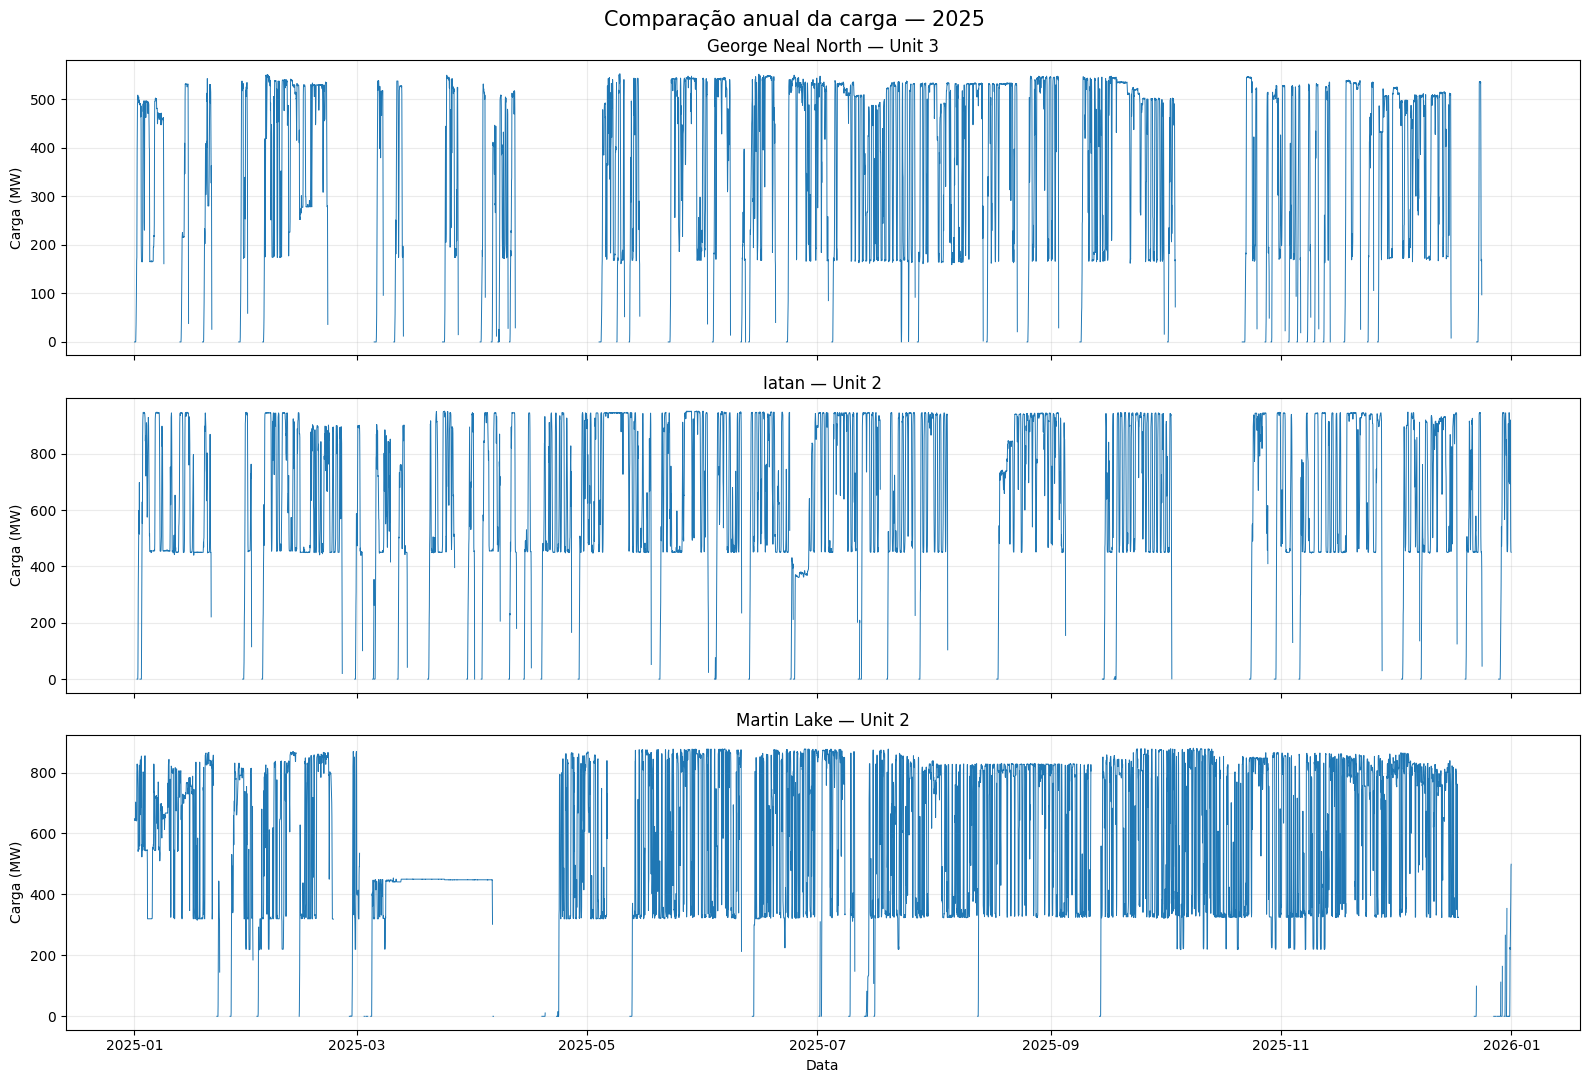

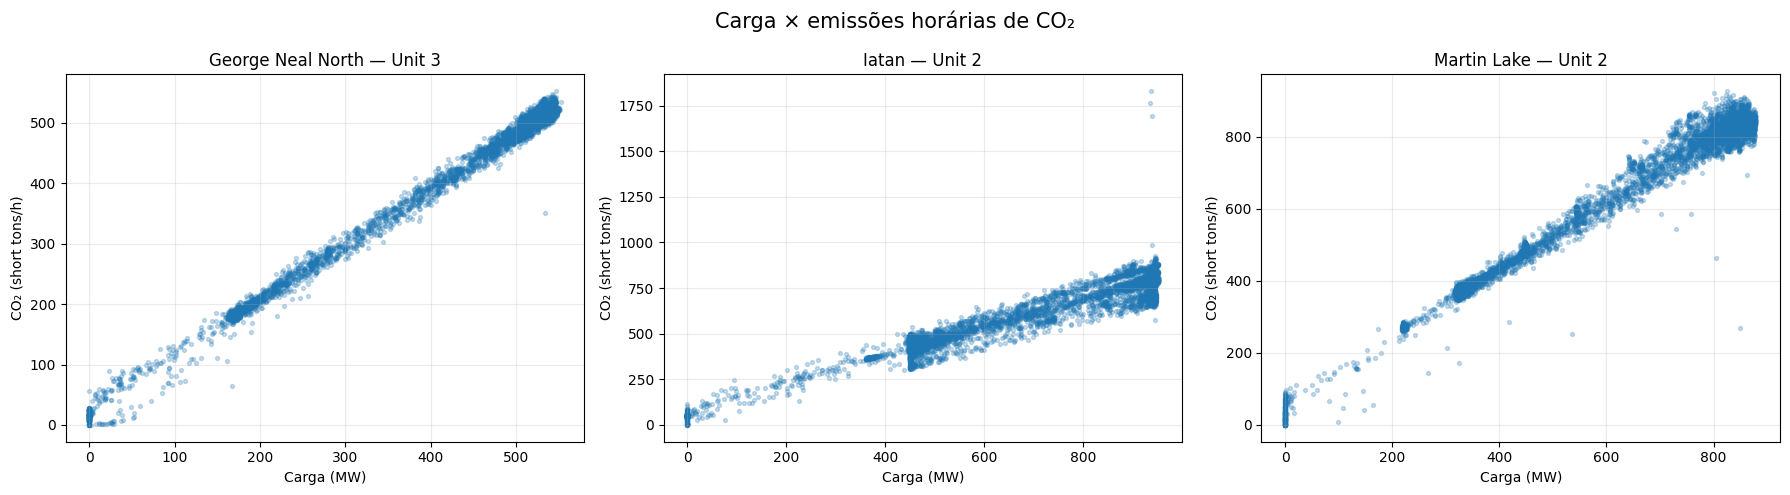

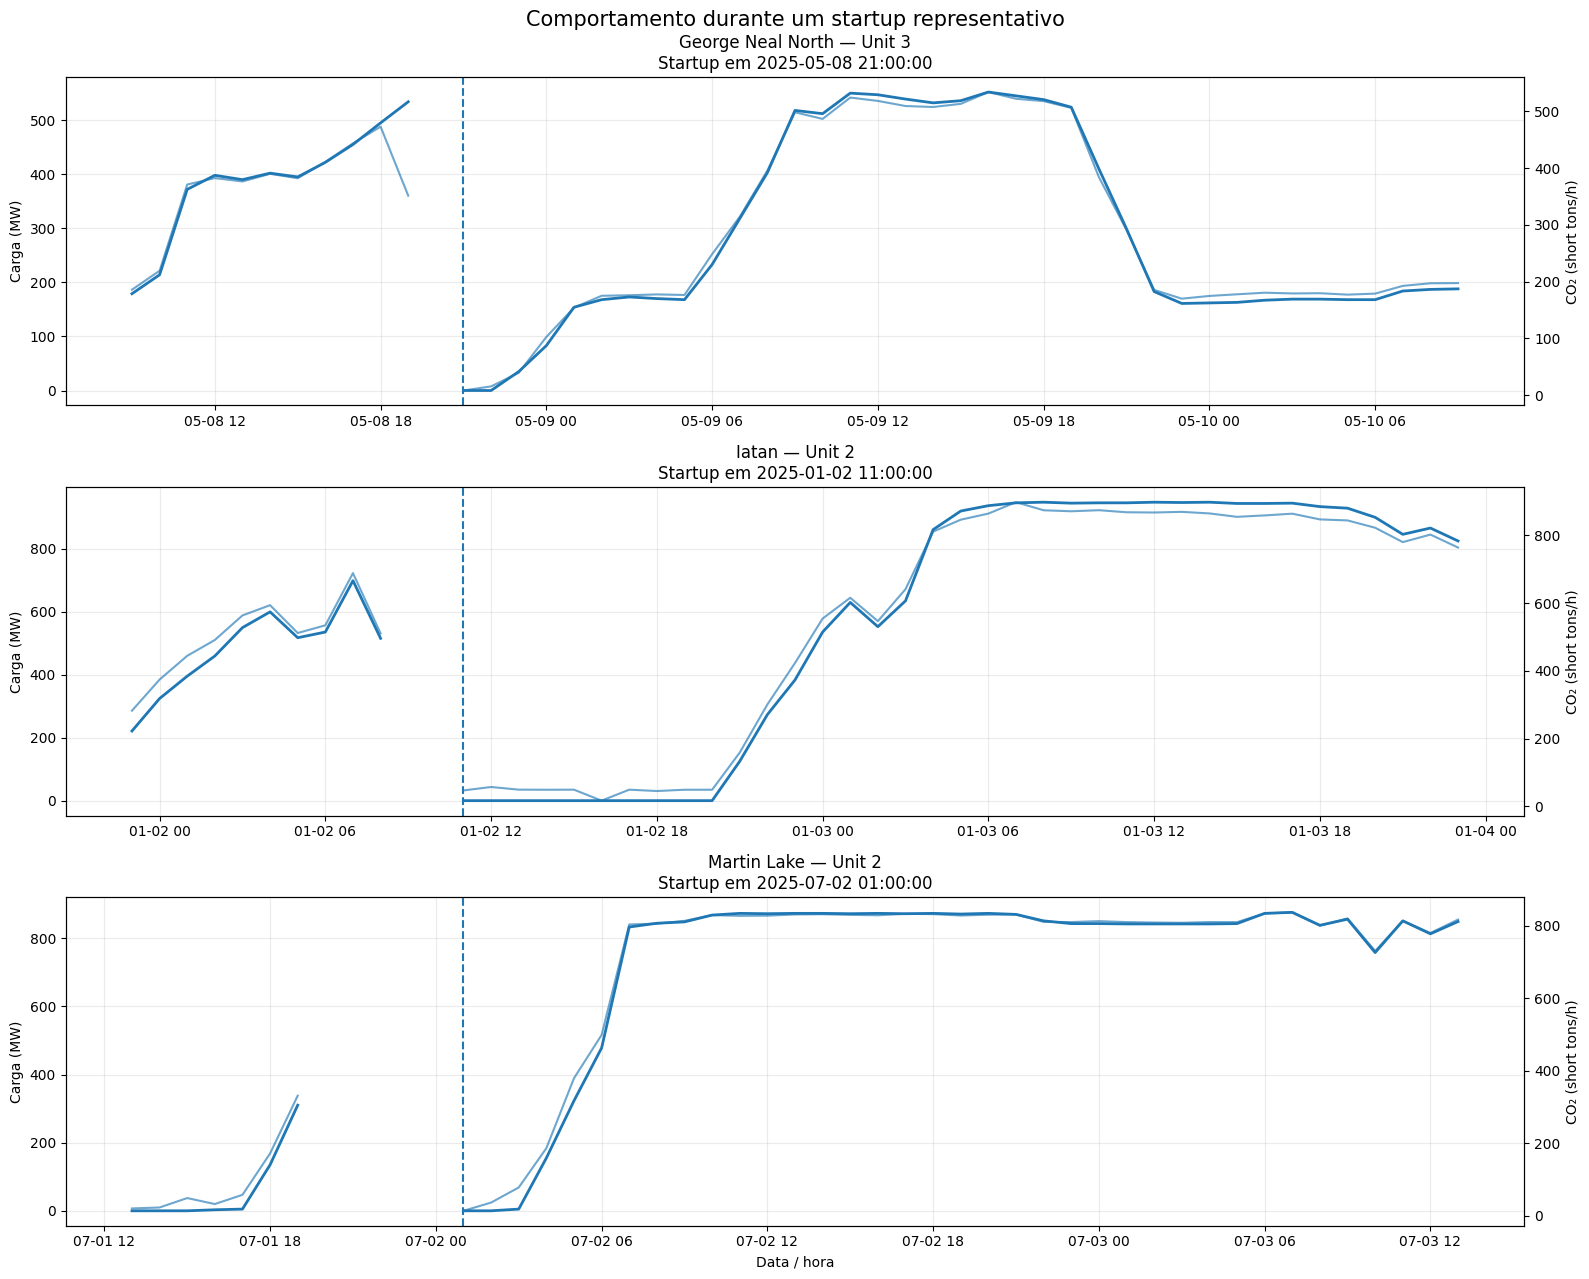


OBSERVAÇÕES PARA INTERPRETAÇÃO

Maior número de transições observadas em 2025:
  George Neal North — Unit 3 — 75 transições

Maior amplitude de carga entre P05 e P95:
  Iatan — Unit 2 — 809.00 MW

Maior intensidade típica de rampas (P95 de |ΔP|):
  Martin Lake — Unit 2 — 301.45 MW/h

Maior proporção de horas operacionais com carga <= 0:
  George Neal North — Unit 3 — 5.07%

INTERPRETAÇÃO METODOLÓGICA

A escolha da unidade para o estudo de caso não deve ser baseada
em um único indicador.

Uma unidade com muitas partidas e paradas é interessante para
o estudo das transições operacionais, porém também é necessário
que existam períodos suficientes de operação estável em
diferentes níveis de carga.

Da mesma forma, uma grande amplitude de carga e a presença de
rampas relevantes aumentam a diversidade operacional da amostra,
o que é desejável para investigar se informações sobre estado
e trajetória operacional ajudam na estimação das emissões de CO2.

A presença de horas classificadas como 

In [80]:
# ============================================================
# ETAPA 11 — COMPARAÇÃO APROFUNDADA DAS TRÊS FINALISTAS
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# A Etapa 10 realizou uma triagem entre as unidades candidatas
# utilizando critérios de qualidade dos dados e riqueza
# operacional.
#
# Três unidades se destacaram:
#
#   1. George Neal North — Unit 3
#   2. Iatan — Unit 2
#   3. Martin Lake — Unit 2
#
# Nesta etapa, NÃO será feita uma escolha automática.
#
# O objetivo é verificar visualmente e quantitativamente se as
# características agregadas observadas na Etapa 10 realmente
# correspondem a comportamentos operacionais interessantes ao
# longo do ano.
#
# Serão avaliados:
#
#   - disponibilidade das 8.760 horas de 2025;
#   - tempo ligado e desligado;
#   - startups e shutdowns observados;
#   - ocorrência de operação com carga igual a zero;
#   - horas parcialmente operacionais;
#   - distribuição e amplitude da carga;
#   - intensidade das variações horárias de carga;
#   - relação entre carga e emissão de CO2;
#   - comportamento durante eventos reais de startup.
#
# Essa análise é importante porque o objetivo do estudo é
# desenvolver uma modelagem orientada ao processo operacional,
# considerando estados e transições, e não apenas utilizar a
# carga instantânea como variável explicativa.
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. DEFINIÇÃO DAS TRÊS FINALISTAS
# ============================================================

finalists_spec = [
    {
        "name": "George Neal North — Unit 3",
        "facilityId": "1091",
        "unitId": "3"
    },
    {
        "name": "Iatan — Unit 2",
        "facilityId": "6065",
        "unitId": "2"
    },
    {
        "name": "Martin Lake — Unit 2",
        "facilityId": "6146",
        "unitId": "2"
    }
]


# ============================================================
# 2. PREPARAR OS DADOS DAS FINALISTAS
# ============================================================

finalist_data = {}


for candidate in finalists_spec:

    name = candidate["name"]
    facility_id = candidate["facilityId"]
    unit_id = candidate["unitId"]


    df = (
        hourly_candidates[
            (
                hourly_candidates["facilityId_norm"].astype(str)
                == facility_id
            )
            &
            (
                hourly_candidates["unitId_norm"].astype(str)
                == unit_id
            )
        ]
        .copy()
        .sort_values("timestamp")
        .reset_index(drop=True)
    )


    if len(df) == 0:

        raise ValueError(
            f"Nenhum dado encontrado para {name}."
        )


    # Garantir tipos numéricos

    df["Operating Time"] = pd.to_numeric(
        df["Operating Time"],
        errors="coerce"
    )

    df["Gross Load (MW)"] = pd.to_numeric(
        df["Gross Load (MW)"],
        errors="coerce"
    )

    df["CO2 Mass (short tons)"] = pd.to_numeric(
        df["CO2 Mass (short tons)"],
        errors="coerce"
    )

    df["timestamp"] = pd.to_datetime(
        df["timestamp"],
        errors="coerce"
    )


    finalist_data[name] = df


print("=" * 70)
print("ETAPA 11 — FINALISTAS CARREGADAS")
print("=" * 70)

for name, df in finalist_data.items():

    print(
        f"{name}: {len(df):,} registros"
    )


# ============================================================
# 3. ANÁLISE OPERACIONAL DETALHADA
# ============================================================
#
# IMPORTANTE:
#
# Nesta etapa, uma unidade é considerada ligada quando:
#
#       Operating Time > 0
#
# Esse critério é preferível a Gross Load > 0 porque uma
# termelétrica pode estar em processo de startup ou shutdown
# dentro de determinada hora, apresentando emissão de CO2 antes
# de atingir carga positiva significativa.
#
# Também NÃO consideramos automaticamente a primeira hora do
# ano como uma startup.
#
# Se a unidade já estava ligada às 00:00 de 01/01/2025, não
# sabemos se a partida ocorreu naquele momento ou ainda em 2024.
# ============================================================


comparison_results = []

startup_examples = {}


for name, df in finalist_data.items():

    g = df.copy()


    # --------------------------------------------------------
    # Estado operacional
    # --------------------------------------------------------

    operating_time = g["Operating Time"]

    load = g["Gross Load (MW)"]

    co2 = g["CO2 Mass (short tons)"]


    on = (
        operating_time
        .fillna(0)
        .gt(0)
        .astype(bool)
    )


    # Estado da hora anterior

    previous_on = on.shift(1)


    # Na primeira hora não inferimos transição,
    # pois não temos a última hora de 2024.

    previous_on.iloc[0] = on.iloc[0]

    previous_on = previous_on.astype(bool)


    # --------------------------------------------------------
    # Startup e shutdown observados DENTRO de 2025
    # --------------------------------------------------------

    startup = (
        on
        &
        (~previous_on)
    )

    shutdown = (
        (~on)
        &
        previous_on
    )


    startups = int(
        startup.sum()
    )

    shutdowns = int(
        shutdown.sum()
    )


    # --------------------------------------------------------
    # Horas ligadas / desligadas
    # --------------------------------------------------------

    operating_hours = int(
        on.sum()
    )

    off_hours = int(
        (~on).sum()
    )


    # --------------------------------------------------------
    # Horas parcialmente operacionais
    #
    # Operating Time varia entre 0 e 1.
    #
    # Valores entre 0 e 1 indicam que a unidade operou apenas
    # durante parte daquela hora.
    #
    # Essas observações são especialmente interessantes para
    # identificar períodos associados a startup ou shutdown.
    # --------------------------------------------------------

    partial_operation = (
        (operating_time > 0)
        &
        (operating_time < 1)
    )

    partial_hours = int(
        partial_operation.sum()
    )


    # --------------------------------------------------------
    # Operação com carga igual ou menor que zero
    #
    # Essa métrica ajuda a investigar casos como George Neal
    # North, onde o P05 da carga apareceu igual a 0 MW.
    #
    # Isso não significa necessariamente erro:
    # pode representar uma fase de startup/shutdown em que a
    # unidade está registrada como operacional, mas ainda não
    # está efetivamente entregando potência.
    # --------------------------------------------------------

    zero_load_while_on = (
        on
        &
        (
            load.fillna(0)
            <= 0
        )
    )


    zero_load_hours = int(
        zero_load_while_on.sum()
    )


    if operating_hours > 0:

        zero_load_share = (
            zero_load_hours
            /
            operating_hours
        )

    else:

        zero_load_share = np.nan


    # --------------------------------------------------------
    # Cobertura de dados
    # --------------------------------------------------------

    if operating_hours > 0:

        co2_coverage = float(
            co2[on]
            .notna()
            .mean()
        )

        load_coverage = float(
            load[on]
            .notna()
            .mean()
        )

    else:

        co2_coverage = np.nan
        load_coverage = np.nan


    # --------------------------------------------------------
    # Percentual de CO2 indicado como medido
    # --------------------------------------------------------

    if (
        "CO2 Mass Measure Indicator"
        in g.columns
        and operating_hours > 0
    ):

        indicator = (
            g.loc[
                on,
                "CO2 Mass Measure Indicator"
            ]
            .astype(str)
            .str.strip()
            .str.lower()
        )


        measured_share = float(
            indicator
            .str.contains(
                "measured",
                na=False
            )
            .mean()
        )

    else:

        measured_share = np.nan


    # --------------------------------------------------------
    # Estatísticas da carga nas horas operacionais
    # --------------------------------------------------------

    load_on = (
        load[on]
        .dropna()
    )


    load_mean = float(
        load_on.mean()
    )

    load_median = float(
        load_on.median()
    )

    load_q05 = float(
        load_on.quantile(0.05)
    )

    load_q95 = float(
        load_on.quantile(0.95)
    )

    load_span = (
        load_q95
        -
        load_q05
    )


    if load_mean != 0:

        load_cv = float(
            load_on.std()
            /
            load_mean
        )

    else:

        load_cv = np.nan


    # --------------------------------------------------------
    # Rampas / variação de carga
    #
    # Ainda NÃO definimos oficialmente um estado chamado
    # "ramp-up" ou "ramp-down".
    #
    # Aqui apenas calculamos:
    #
    #       Delta P(t) = P(t) - P(t-1)
    #
    # para avaliar quão dinâmica é a operação.
    # --------------------------------------------------------

    delta_load = load.diff()

    abs_delta_load = (
        delta_load[on]
        .abs()
        .dropna()
    )


    delta_q95 = float(
        abs_delta_load.quantile(0.95)
    )

    delta_max = float(
        abs_delta_load.max()
    )


    # --------------------------------------------------------
    # Maior aumento de carga em uma hora
    # --------------------------------------------------------

    max_ramp_up = float(
        delta_load.max()
    )


    # --------------------------------------------------------
    # Maior redução de carga em uma hora
    # --------------------------------------------------------

    max_ramp_down = float(
        delta_load.min()
    )


    # --------------------------------------------------------
    # Selecionar um startup representativo
    #
    # Para cada startup observado, analisamos as 24 horas
    # seguintes.
    #
    # O evento representativo será aquele em que a unidade
    # atingir a maior carga nesse intervalo.
    #
    # Isso tende a selecionar uma partida operacionalmente
    # relevante para inspeção visual.
    # --------------------------------------------------------

    startup_indices = np.where(
        startup.to_numpy()
    )[0]


    best_startup_index = None
    best_future_load = -np.inf


    for idx in startup_indices:

        end_idx = min(
            idx + 24,
            len(g)
        )


        future_load = (
            load.iloc[
                idx:end_idx
            ]
            .max()
        )


        if (
            pd.notna(future_load)
            and future_load > best_future_load
        ):

            best_future_load = future_load
            best_startup_index = idx


    if best_startup_index is not None:

        startup_timestamp = (
            g.loc[
                best_startup_index,
                "timestamp"
            ]
        )

    else:

        startup_timestamp = pd.NaT


    startup_examples[name] = (
        startup_timestamp
    )


    # --------------------------------------------------------
    # Guardar resultados
    # --------------------------------------------------------

    comparison_results.append({

        "candidate":
            name,

        "rows_2025":
            len(g),

        "operating_hours":
            operating_hours,

        "off_hours":
            off_hours,

        "startups_2025":
            startups,

        "shutdowns_2025":
            shutdowns,

        "transitions_2025":
            startups + shutdowns,

        "partial_operation_hours":
            partial_hours,

        "zero_load_while_on_hours":
            zero_load_hours,

        "zero_load_while_on_share":
            zero_load_share,

        "co2_coverage":
            co2_coverage,

        "load_coverage":
            load_coverage,

        "measured_share":
            measured_share,

        "load_mean_mw":
            load_mean,

        "load_median_mw":
            load_median,

        "load_q05_mw":
            load_q05,

        "load_q95_mw":
            load_q95,

        "load_span_q05_q95_mw":
            load_span,

        "load_cv":
            load_cv,

        "abs_delta_load_q95_mw":
            delta_q95,

        "max_ramp_up_mw":
            max_ramp_up,

        "max_ramp_down_mw":
            max_ramp_down,

        "representative_startup":
            startup_timestamp
    })


# ============================================================
# 4. TABELA COMPARATIVA
# ============================================================

comparison = pd.DataFrame(
    comparison_results
)


print("\n" + "=" * 70)
print("COMPARAÇÃO NUMÉRICA DAS FINALISTAS")
print("=" * 70)


display(
    comparison
    .round({
        "zero_load_while_on_share": 4,
        "co2_coverage": 4,
        "load_coverage": 4,
        "measured_share": 4,
        "load_mean_mw": 2,
        "load_median_mw": 2,
        "load_q05_mw": 2,
        "load_q95_mw": 2,
        "load_span_q05_q95_mw": 2,
        "load_cv": 3,
        "abs_delta_load_q95_mw": 2,
        "max_ramp_up_mw": 2,
        "max_ramp_down_mw": 2
    })
)


# ============================================================
# 5. GRÁFICO 1 — CARGA AO LONGO DE 2025
# ============================================================
#
# MOTIVAÇÃO:
#
# A série anual permite observar:
#
#   - grandes paradas;
#   - períodos prolongados em diferentes níveis de carga;
#   - sazonalidade;
#   - frequência de mudanças operacionais;
#   - possíveis padrões atípicos.
#
# Queremos uma unidade que tenha comportamento suficientemente
# variável para representar diferentes estados operacionais,
# sem apresentar uma série dominada por inconsistências.
# ============================================================


fig, axes = plt.subplots(
    3,
    1,
    figsize=(16, 11),
    sharex=True
)


for ax, (name, df) in zip(
    axes,
    finalist_data.items()
):

    ax.plot(
        df["timestamp"],
        df["Gross Load (MW)"],
        linewidth=0.7
    )

    ax.set_title(
        name
    )

    ax.set_ylabel(
        "Carga (MW)"
    )

    ax.grid(
        alpha=0.25
    )


axes[-1].set_xlabel(
    "Data"
)


fig.suptitle(
    "Comparação anual da carga — 2025",
    fontsize=15
)


plt.tight_layout()

plt.show()


# ============================================================
# 6. GRÁFICO 2 — RELAÇÃO ENTRE CARGA E EMISSÃO DE CO2
# ============================================================
#
# MOTIVAÇÃO:
#
# Se a emissão de CO2 dependesse exclusivamente da carga
# instantânea, seria esperada uma relação relativamente simples
# e concentrada entre as duas variáveis.
#
# Dispersões diferentes para cargas semelhantes podem indicar
# influência de outros fatores, incluindo:
#
#   - estado operacional;
#   - trajetória anterior da unidade;
#   - startup;
#   - ramp-up;
#   - ramp-down;
#   - diferenças de eficiência operacional.
#
# Essa é justamente uma das motivações centrais do estudo.
# ============================================================


fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)


for ax, (name, df) in zip(
    axes,
    finalist_data.items()
):

    valid = df[
        df["Gross Load (MW)"].notna()
        &
        df["CO2 Mass (short tons)"].notna()
        &
        (df["Operating Time"] > 0)
    ]


    ax.scatter(
        valid["Gross Load (MW)"],
        valid["CO2 Mass (short tons)"],
        s=8,
        alpha=0.25
    )


    ax.set_title(
        name
    )

    ax.set_xlabel(
        "Carga (MW)"
    )

    ax.set_ylabel(
        "CO₂ (short tons/h)"
    )

    ax.grid(
        alpha=0.25
    )


fig.suptitle(
    "Carga × emissões horárias de CO₂",
    fontsize=15
)


plt.tight_layout()

plt.show()


# ============================================================
# 7. GRÁFICO 3 — STARTUP REPRESENTATIVO
# ============================================================
#
# MOTIVAÇÃO:
#
# Para cada unidade selecionamos automaticamente um startup
# observado durante 2025.
#
# É exibida uma janela de:
#
#       12 horas antes
#       +
#       36 horas depois
#
# Isso permite observar de forma concreta:
#
#   OFF
#     ↓
#   STARTUP
#     ↓
#   RAMP-UP
#     ↓
#   OPERAÇÃO
#
# e comparar simultaneamente o comportamento da carga e das
# emissões de CO2.
#
# Ainda NÃO estamos classificando formalmente esses estados.
# Esta análise é exploratória e servirá para fundamentar a
# definição posterior dos critérios de classificação.
# ============================================================


fig, axes = plt.subplots(
    3,
    1,
    figsize=(16, 13)
)


for ax, (name, df) in zip(
    axes,
    finalist_data.items()
):


    startup_time = (
        startup_examples[name]
    )


    if pd.isna(startup_time):

        ax.text(
            0.5,
            0.5,
            "Nenhum startup identificado",
            ha="center",
            va="center",
            transform=ax.transAxes
        )

        ax.set_title(
            name
        )

        continue


    start_window = (
        startup_time
        -
        pd.Timedelta(hours=12)
    )


    end_window = (
        startup_time
        +
        pd.Timedelta(hours=36)
    )


    window = df[
        (
            df["timestamp"]
            >= start_window
        )
        &
        (
            df["timestamp"]
            <= end_window
        )
    ]


    # Carga

    ax.plot(
        window["timestamp"],
        window["Gross Load (MW)"],
        linewidth=2,
        label="Carga (MW)"
    )


    ax.axvline(
        startup_time,
        linestyle="--",
        linewidth=1.5,
        label="Startup identificado"
    )


    ax.set_ylabel(
        "Carga (MW)"
    )


    ax.set_title(
        f"{name}\nStartup em {startup_time}"
    )


    ax.grid(
        alpha=0.25
    )


    # CO2 em segundo eixo

    ax2 = ax.twinx()


    ax2.plot(
        window["timestamp"],
        window["CO2 Mass (short tons)"],
        linewidth=1.5,
        alpha=0.65,
        label="CO₂"
    )


    ax2.set_ylabel(
        "CO₂ (short tons/h)"
    )


axes[-1].set_xlabel(
    "Data / hora"
)


fig.suptitle(
    "Comportamento durante um startup representativo",
    fontsize=15
)


plt.tight_layout()

plt.show()


# ============================================================
# 8. OBSERVAÇÕES AUTOMÁTICAS PARA A APRESENTAÇÃO
# ============================================================
#
# Este bloco NÃO decide qual unidade deve ser escolhida.
#
# Ele apenas identifica extremos relevantes entre as três
# finalistas para facilitar a interpretação dos resultados.
# ============================================================


most_transitions = comparison.loc[
    comparison["transitions_2025"].idxmax()
]


widest_range = comparison.loc[
    comparison["load_span_q05_q95_mw"].idxmax()
]


largest_ramps = comparison.loc[
    comparison["abs_delta_load_q95_mw"].idxmax()
]


most_zero_load = comparison.loc[
    comparison["zero_load_while_on_share"].idxmax()
]


print("\n" + "=" * 70)
print("OBSERVAÇÕES PARA INTERPRETAÇÃO")
print("=" * 70)


print(
    "\nMaior número de transições observadas em 2025:"
)

print(
    f"  {most_transitions['candidate']}"
    f" — {int(most_transitions['transitions_2025'])} transições"
)


print(
    "\nMaior amplitude de carga entre P05 e P95:"
)

print(
    f"  {widest_range['candidate']}"
    f" — {widest_range['load_span_q05_q95_mw']:.2f} MW"
)


print(
    "\nMaior intensidade típica de rampas (P95 de |ΔP|):"
)

print(
    f"  {largest_ramps['candidate']}"
    f" — {largest_ramps['abs_delta_load_q95_mw']:.2f} MW/h"
)


print(
    "\nMaior proporção de horas operacionais com carga <= 0:"
)

print(
    f"  {most_zero_load['candidate']}"
    f" — {100 * most_zero_load['zero_load_while_on_share']:.2f}%"
)


# ============================================================
# 9. INTERPRETAÇÃO METODOLÓGICA
# ============================================================

print("\n" + "=" * 70)
print("INTERPRETAÇÃO METODOLÓGICA")
print("=" * 70)


print(
"""
A escolha da unidade para o estudo de caso não deve ser baseada
em um único indicador.

Uma unidade com muitas partidas e paradas é interessante para
o estudo das transições operacionais, porém também é necessário
que existam períodos suficientes de operação estável em
diferentes níveis de carga.

Da mesma forma, uma grande amplitude de carga e a presença de
rampas relevantes aumentam a diversidade operacional da amostra,
o que é desejável para investigar se informações sobre estado
e trajetória operacional ajudam na estimação das emissões de CO2.

A presença de horas classificadas como operacionais com carga
igual ou próxima de zero deve ser analisada com atenção. Esses
casos podem representar fases reais de startup ou shutdown e,
portanto, podem ser cientificamente relevantes; entretanto,
também precisam ser compreendidos antes da escolha definitiva
da unidade.

Os gráficos desta etapa devem ser utilizados juntamente com os
indicadores quantitativos para selecionar a unidade que ofereça
o melhor equilíbrio entre qualidade dos dados, interpretabilidade
física e diversidade de comportamento operacional.
"""
)

In [81]:
# ============================================================
# ETAPA 12 — SELEÇÃO DEFINITIVA DA UNIDADE DE ESTUDO
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Após a triagem das unidades candidatas e a comparação
# aprofundada das três finalistas, seleciona-se uma única
# unidade para o desenvolvimento do estudo de caso.
#
# UNIDADE SELECIONADA:
#
#   Iatan — Unit 2
#   Facility ID: 6065
#   Estado: Missouri (MO)
#   Combustível principal: Coal
#   Tipo: Dry bottom wall-fired boiler
#
# ------------------------------------------------------------
# JUSTIFICATIVA DA ESCOLHA
# ------------------------------------------------------------
#
# A seleção não foi baseada exclusivamente na posição de um
# ranking ou em um único indicador.
#
# Foram considerados conjuntamente:
#
#   1. completude dos dados horários de 2025;
#   2. disponibilidade de CO2 monitorado por CEMS;
#   3. disponibilidade de carga horária;
#   4. número de startups e shutdowns;
#   5. presença de períodos ligados e desligados;
#   6. amplitude da carga operacional;
#   7. intensidade das variações horárias de carga;
#   8. interpretabilidade do comportamento operacional.
#
# Entre as três finalistas:
#
# GEORGE NEAL NORTH — UNIT 3
#   - 75 transições;
#   - elevada variabilidade;
#   - porém aproximadamente 5% das horas classificadas como
#     operacionais apresentam carga <= 0 MW;
#   - P05 da carga = 0 MW.
#
# MARTIN LAKE — UNIT 2
#   - 70 transições;
#   - elevada disponibilidade operacional;
#   - rampas particularmente intensas;
#   - P95 de |Delta P| = 301,45 MW/h.
#
# IATAN — UNIT 2
#   - 75 transições observadas em 2025;
#   - 38 startups e 37 shutdowns;
#   - 6.249 horas operacionais;
#   - 2.511 horas desligada;
#   - P05 da carga = 136 MW;
#   - P95 da carga = 945 MW;
#   - amplitude P05-P95 = 809 MW;
#   - P95 de |Delta P| = 175,5 MW/h;
#   - apenas cerca de 3,95% das horas operacionais apresentam
#     carga <= 0 MW.
#
# Dessa forma, Iatan 2 apresenta uma combinação particularmente
# adequada entre qualidade dos dados e diversidade operacional.
#
# A unidade contém número elevado de partidas e paradas e,
# simultaneamente, apresenta operação em uma ampla faixa de
# carga, permitindo investigar diferentes regimes operacionais.
#
# Essa característica é especialmente importante para a
# proposta do estudo, que busca verificar se informações sobre
# estado e trajetória operacional contribuem para a estimação
# das emissões horárias de CO2.
# ============================================================


import numpy as np
import pandas as pd


# ============================================================
# 1. DEFINIR A UNIDADE SELECIONADA
# ============================================================

SELECTED_FACILITY_ID = "6065"

SELECTED_UNIT_ID = "2"

SELECTED_FACILITY_NAME = "Iatan"

SELECTED_STATE = "MO"


print("=" * 70)
print("UNIDADE DEFINITIVA DO ESTUDO DE CASO")
print("=" * 70)

print(
    "Usina:",
    SELECTED_FACILITY_NAME
)

print(
    "Facility ID:",
    SELECTED_FACILITY_ID
)

print(
    "Unit ID:",
    SELECTED_UNIT_ID
)

print(
    "Estado:",
    SELECTED_STATE
)


# ============================================================
# 2. EXTRAIR SOMENTE IATAN — UNIT 2
# ============================================================

iatan_2025 = (
    hourly_candidates[
        (
            hourly_candidates[
                "facilityId_norm"
            ].astype(str)
            == SELECTED_FACILITY_ID
        )
        &
        (
            hourly_candidates[
                "unitId_norm"
            ].astype(str)
            == SELECTED_UNIT_ID
        )
    ]
    .copy()
    .sort_values(
        "timestamp"
    )
    .reset_index(drop=True)
)


# ============================================================
# 3. VERIFICAÇÕES BÁSICAS
# ============================================================

if len(iatan_2025) == 0:

    raise ValueError(
        "Nenhum registro encontrado para "
        "Iatan — Unit 2."
    )


if len(iatan_2025) != 8760:

    print(
        "ATENÇÃO: foram encontrados",
        len(iatan_2025),
        "registros, e não 8.760."
    )


print(
    "\nRegistros horários:",
    f"{len(iatan_2025):,}"
)

print(
    "Período:",
    iatan_2025["timestamp"].min(),
    "→",
    iatan_2025["timestamp"].max()
)


# ============================================================
# 4. GARANTIR TIPOS NUMÉRICOS
# ============================================================

numeric_columns = [
    "Operating Time",
    "Gross Load (MW)",
    "CO2 Mass (short tons)"
]


for col in numeric_columns:

    iatan_2025[col] = pd.to_numeric(
        iatan_2025[col],
        errors="coerce"
    )


iatan_2025["timestamp"] = pd.to_datetime(
    iatan_2025["timestamp"],
    errors="coerce"
)


# ============================================================
# 5. CRIAR VARIÁVEIS OPERACIONAIS BÁSICAS
# ============================================================
#
# Neste momento criamos apenas variáveis diretamente derivadas
# da sequência temporal.
#
# Ainda NÃO estamos classificando formalmente os estados:
#
#   startup
#   ramp-up
#   low load
#   medium load
#   high load
#   ramp-down
#   shutdown
#
# Essa classificação será definida na próxima etapa.
# ============================================================


# ------------------------------------------------------------
# Estado ligado/desligado
# ------------------------------------------------------------

iatan_2025["is_on"] = (
    iatan_2025["Operating Time"]
    .fillna(0)
    .gt(0)
)


# ------------------------------------------------------------
# Carga da hora anterior
# ------------------------------------------------------------

iatan_2025["load_lag_1h"] = (
    iatan_2025[
        "Gross Load (MW)"
    ]
    .shift(1)
)


# ------------------------------------------------------------
# Variação horária da carga
#
# Delta P(t) = P(t) - P(t-1)
# ------------------------------------------------------------

iatan_2025["delta_load_1h"] = (
    iatan_2025[
        "Gross Load (MW)"
    ]
    -
    iatan_2025[
        "load_lag_1h"
    ]
)


# ------------------------------------------------------------
# CO2 da hora anterior
#
# IMPORTANTE:
# Esta variável é criada para ANÁLISE EXPLORATÓRIA.
#
# Ela NÃO deverá ser automaticamente utilizada como preditora
# do modelo sem discussão metodológica, pois o objetivo é
# construir uma abordagem reproduzível para estimação de CO2.
# ------------------------------------------------------------

iatan_2025["co2_lag_1h"] = (
    iatan_2025[
        "CO2 Mass (short tons)"
    ]
    .shift(1)
)


# ------------------------------------------------------------
# Operating Time da hora anterior
# ------------------------------------------------------------

iatan_2025["operating_time_lag_1h"] = (
    iatan_2025[
        "Operating Time"
    ]
    .shift(1)
)


# ============================================================
# 6. IDENTIFICAR TRANSIÇÕES BÁSICAS
# ============================================================

previous_on = (
    iatan_2025["is_on"]
    .shift(1)
)


# Primeira observação:
# não inferimos transição em relação a 2024.

previous_on.iloc[0] = (
    iatan_2025.loc[
        0,
        "is_on"
    ]
)

previous_on = (
    previous_on
    .astype(bool)
)


iatan_2025["startup_event"] = (
    iatan_2025["is_on"]
    &
    (~previous_on)
)


iatan_2025["shutdown_event"] = (
    (~iatan_2025["is_on"])
    &
    previous_on
)


# ============================================================
# 7. RESUMO DA UNIDADE SELECIONADA
# ============================================================

operating_hours = int(
    iatan_2025[
        "is_on"
    ].sum()
)

off_hours = int(
    (
        ~iatan_2025[
            "is_on"
        ]
    ).sum()
)

startups = int(
    iatan_2025[
        "startup_event"
    ].sum()
)

shutdowns = int(
    iatan_2025[
        "shutdown_event"
    ].sum()
)


load_on = (
    iatan_2025.loc[
        iatan_2025["is_on"],
        "Gross Load (MW)"
    ]
    .dropna()
)


print("\n" + "=" * 70)
print("RESUMO DA UNIDADE SELECIONADA")
print("=" * 70)

print(
    "Horas operacionais:",
    operating_hours
)

print(
    "Horas desligada:",
    off_hours
)

print(
    "Startups observados:",
    startups
)

print(
    "Shutdowns observados:",
    shutdowns
)

print(
    "Carga média durante operação:",
    round(
        load_on.mean(),
        2
    ),
    "MW"
)

print(
    "Carga mediana durante operação:",
    round(
        load_on.median(),
        2
    ),
    "MW"
)

print(
    "P05 da carga:",
    round(
        load_on.quantile(0.05),
        2
    ),
    "MW"
)

print(
    "P95 da carga:",
    round(
        load_on.quantile(0.95),
        2
    ),
    "MW"
)


# ============================================================
# 8. VERIFICAR VALORES AUSENTES
# ============================================================

missing_summary = pd.DataFrame({

    "variavel": [
        "Operating Time",
        "Gross Load (MW)",
        "CO2 Mass (short tons)"
    ],

    "ausentes": [
        iatan_2025[
            "Operating Time"
        ].isna().sum(),

        iatan_2025[
            "Gross Load (MW)"
        ].isna().sum(),

        iatan_2025[
            "CO2 Mass (short tons)"
        ].isna().sum()
    ]
})


missing_summary["percentual"] = (
    100
    *
    missing_summary["ausentes"]
    /
    len(iatan_2025)
)


print("\n" + "=" * 70)
print("VALORES AUSENTES")
print("=" * 70)


display(
    missing_summary
)


# ============================================================
# 9. VISUALIZAR PRIMEIROS REGISTROS
# ============================================================

display_columns = [
    "timestamp",
    "Operating Time",
    "Gross Load (MW)",
    "CO2 Mass (short tons)",
    "is_on",
    "load_lag_1h",
    "delta_load_1h",
    "startup_event",
    "shutdown_event"
]


print("\nPrimeiros registros do dataset do estudo:")


display(
    iatan_2025[
        display_columns
    ]
    .head(24)
)


# ============================================================
# 10. CONCLUSÃO METODOLÓGICA
# ============================================================

print("\n" + "=" * 70)
print("DECISÃO METODOLÓGICA")
print("=" * 70)


print(
"""
A unidade Iatan — Unit 2 foi selecionada como estudo de caso.

A escolha decorre do equilíbrio entre:

- completude e qualidade dos dados;
- elevada quantidade de transições operacionais;
- presença significativa de períodos ligados e desligados;
- ampla faixa de operação em carga;
- ocorrência de variações horárias relevantes de potência;
- possibilidade de observar diferentes regimes de operação.

A partir desta etapa, as análises deixam de considerar o
conjunto de usinas candidatas e passam a utilizar exclusivamente
os 8.760 registros horários de Iatan — Unit 2 referentes ao ano
de 2025.

O próximo passo consiste em definir formalmente os estados
operacionais da unidade e construir as variáveis que descrevem
sua trajetória operacional ao longo do tempo.
"""
)

UNIDADE DEFINITIVA DO ESTUDO DE CASO
Usina: Iatan
Facility ID: 6065
Unit ID: 2
Estado: MO

Registros horários: 8,760
Período: 2025-01-01 00:00:00 → 2025-12-31 23:00:00

RESUMO DA UNIDADE SELECIONADA
Horas operacionais: 6249
Horas desligada: 2511
Startups observados: 38
Shutdowns observados: 37
Carga média durante operação: 666.3 MW
Carga mediana durante operação: 696.0 MW
P05 da carga: 136.0 MW
P95 da carga: 945.0 MW

VALORES AUSENTES


,variavel,ausentes,percentual
0,Operating Time,0,0.000000
1,Gross Load (MW),2511,28.664384
2,CO2 Mass (short tons),2511,28.664384



Primeiros registros do dataset do estudo:


,timestamp,Operating Time,Gross Load (MW),CO2 Mass (short tons),is_on,load_lag_1h,delta_load_1h,startup_event,shutdown_event
0,2025-01-01 00:00:00,0.00,NaN,NaN,False,NaN,NaN,False,False
1,2025-01-01 01:00:00,0.00,NaN,NaN,False,NaN,NaN,False,False
2,2025-01-01 02:00:00,0.00,NaN,NaN,False,NaN,NaN,False,False
3,2025-01-01 03:00:00,0.00,NaN,NaN,False,NaN,NaN,False,False
4,2025-01-01 04:00:00,0.00,NaN,NaN,False,NaN,NaN,False,False
5,2025-01-01 05:00:00,0.00,NaN,NaN,False,NaN,NaN,False,False
6,2025-01-01 06:00:00,0.00,NaN,NaN,False,NaN,NaN,False,False
7,2025-01-01 07:00:00,0.00,NaN,NaN,False,NaN,NaN,False,False
8,2025-01-01 08:00:00,0.00,NaN,NaN,False,NaN,NaN,False,False
9,2025-01-01 09:00:00,0.00,NaN,NaN,False,NaN,NaN,False,False



DECISÃO METODOLÓGICA

A unidade Iatan — Unit 2 foi selecionada como estudo de caso.

A escolha decorre do equilíbrio entre:

- completude e qualidade dos dados;
- elevada quantidade de transições operacionais;
- presença significativa de períodos ligados e desligados;
- ampla faixa de operação em carga;
- ocorrência de variações horárias relevantes de potência;
- possibilidade de observar diferentes regimes de operação.

A partir desta etapa, as análises deixam de considerar o
conjunto de usinas candidatas e passam a utilizar exclusivamente
os 8.760 registros horários de Iatan — Unit 2 referentes ao ano
de 2025.

O próximo passo consiste em definir formalmente os estados
operacionais da unidade e construir as variáveis que descrevem
sua trajetória operacional ao longo do tempo.



In [88]:
# ============================================================
# ETAPA 13 — RELATÓRIO DA SELEÇÃO DA UNIDADE DE ESTUDO
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Consolidar, de forma objetiva e reproduzível, o procedimento
# realizado entre as Etapas 1 e 12.
#
# O relatório documenta:
#
#   - origem dos dados;
#   - critérios de filtragem;
#   - identificação de monitoramento CEMS;
#   - extração dos dados horários;
#   - avaliação de qualidade;
#   - comparação das unidades finalistas;
#   - justificativa da seleção de Iatan — Unit 2.
#
# Este relatório poderá ser utilizado como base para a seção
# metodológica e para a apresentação do trabalho.
# ============================================================


from pathlib import Path
from IPython.display import display, Markdown
import pandas as pd


# ============================================================
# 1. RECUPERAR OS PRINCIPAIS NÚMEROS DO PIPELINE
# ============================================================

n_initial_candidates = len(candidates_meta)

n_monitoring_plans = len(mp_candidates)

n_co2_cem_records = len(co2_cem)

n_cem_2025 = len(cem_2025)

n_structural_candidates = len(candidates)

n_hourly_units = (
    hourly_candidates[
        [
            "facilityId_norm",
            "unitId_norm"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

n_quality_candidates = len(
    quality_candidates
)


# ============================================================
# 2. INDICADORES DA UNIDADE SELECIONADA
# ============================================================

n_records_selected = len(
    iatan_2025
)

operating_hours = int(
    iatan_2025[
        "is_on"
    ].sum()
)

off_hours = int(
    (
        ~iatan_2025[
            "is_on"
        ]
    ).sum()
)

startups = int(
    iatan_2025[
        "startup_event"
    ].sum()
)

shutdowns = int(
    iatan_2025[
        "shutdown_event"
    ].sum()
)


load_on = (
    iatan_2025.loc[
        iatan_2025["is_on"],
        "Gross Load (MW)"
    ]
    .dropna()
)


load_mean = (
    load_on.mean()
)

load_median = (
    load_on.median()
)

load_q05 = (
    load_on.quantile(0.05)
)

load_q95 = (
    load_on.quantile(0.95)
)

load_span = (
    load_q95
    -
    load_q05
)


# ============================================================
# 3. INFORMAÇÕES DA COMPARAÇÃO ENTRE FINALISTAS
# ============================================================

iatan_comparison = comparison[
    comparison["candidate"]
    ==
    "Iatan — Unit 2"
].iloc[0]


george_comparison = comparison[
    comparison["candidate"]
    ==
    "George Neal North — Unit 3"
].iloc[0]


martin_comparison = comparison[
    comparison["candidate"]
    ==
    "Martin Lake — Unit 2"
].iloc[0]


# ============================================================
# 4. CONSTRUIR RELATÓRIO
# ============================================================

report = f"""
# Relatório de seleção da unidade termelétrica

## 1. Objetivo da etapa de seleção

O objetivo desta primeira fase do estudo foi selecionar uma
unidade termelétrica a carvão adequada para o desenvolvimento
de um modelo de estimação das emissões horárias de CO₂.

A unidade deveria possuir dados horários ao longo de 2025,
monitoramento de CO₂ por CEMS e comportamento operacional
suficientemente variável para permitir posteriormente a análise
de estados e transições de operação.

A seleção foi realizada a partir dos dados disponibilizados pela
U.S. Environmental Protection Agency (EPA).


## 2. Etapa 1 — Configuração e acesso aos dados

Inicialmente foi configurado o ambiente de trabalho no Google
Colab, incluindo o acesso à API da EPA e a definição dos
diretórios utilizados para armazenamento temporário e saída dos
dados.

A utilização da API permite que a obtenção dos dados seja
reproduzível, evitando a seleção manual de arquivos.


## 3. Etapa 2 — Consulta ao catálogo de dados da EPA

Foi consultado o catálogo de arquivos disponibilizados pela EPA.

O objetivo foi identificar programaticamente os conjuntos de
dados necessários ao estudo, principalmente:

- informações sobre instalações e unidades;
- Monitoring Plans;
- arquivos de emissões horárias de 2025.

Essa estratégia permite rastrear exatamente quais fontes foram
utilizadas no processamento.


## 4. Etapa 3 — Identificação da população inicial

A população de unidades foi filtrada considerando unidades
associadas ao uso de carvão e tecnologias de caldeira
compatíveis com geração termelétrica a vapor.

Após essa filtragem foram identificadas:

**{n_initial_candidates} unidades candidatas iniciais.**

Essa etapa reduz o universo da base da EPA às unidades
tecnologicamente compatíveis com o objeto do estudo.


## 5. Etapa 4 — Associação aos Monitoring Plans

Os identificadores das instalações candidatas foram cruzados com
os arquivos de Monitoring Plan da EPA.

Foram encontrados:

**{n_monitoring_plans} Monitoring Plans associados às instalações
candidatas.**

Os Monitoring Plans são necessários para verificar como o CO₂ é
monitorado em cada unidade.


## 6. Etapa 5 — Obtenção dos Monitoring Plans

Os arquivos de Monitoring Plan correspondentes às instalações
candidatas foram obtidos para análise.

Essa etapa possibilitou acessar a estrutura de monitoramento de
cada unidade e identificar o método utilizado para determinação
das emissões de CO₂.


## 7. Etapa 6 — Identificação do monitoramento de CO₂ por CEMS

Os arquivos XML dos Monitoring Plans foram processados
individualmente.

Foram procurados registros nos quais:

- o parâmetro monitorado fosse CO₂;
- o método de monitoramento fosse CEM;
- o monitoramento estivesse associado diretamente à unidade.

Foram identificados:

**{n_co2_cem_records} registros de monitoramento CO₂-CEM.**

A exigência de CEMS foi adotada para utilizar como referência
emissões obtidas por monitoramento contínuo da unidade.


## 8. Etapa 7 — Validade do CEMS em 2025

Os registros de monitoramento foram avaliados quanto à validade
durante o período analisado.

Foram identificados:

**{n_cem_2025} registros CO₂-CEM válidos para 2025.**

Após o cruzamento com a população inicial, restaram:

**{n_structural_candidates} unidades candidatas.**

Essas unidades constituíram a população efetivamente elegível
para a análise dos dados horários.


## 9. Etapa 8 — Identificação dos arquivos horários

Foram identificados no catálogo da EPA os arquivos estaduais de
emissões horárias referentes ao ano de 2025.

Os arquivos correspondentes aos estados que possuíam unidades
candidatas foram selecionados para processamento.

Essa abordagem evitou o download de arquivos sem relação com a
população analisada.


## 10. Etapa 9 — Extração dos dados horários

Os arquivos estaduais de 2025 foram processados e somente os
registros pertencentes às unidades candidatas foram mantidos.

Foram obtidas:

**{n_hourly_units} unidades com dados horários em 2025.**

Cada unidade encontrada possuía até 8.760 observações, que
correspondem às horas de um ano não bissexto.

Essa etapa confirmou a disponibilidade temporal dos dados
necessários ao estudo.


## 11. Etapa 10 — Avaliação da qualidade e riqueza operacional

As unidades foram avaliadas segundo critérios de qualidade dos
dados e diversidade de comportamento operacional.

Foram considerados, entre outros:

- cobertura dos dados de CO₂;
- cobertura dos dados de carga;
- proporção de valores indicados como medidos;
- presença de operação ao longo dos meses do ano;
- número de startups e shutdowns;
- amplitude da carga;
- variabilidade da carga;
- intensidade das variações horárias de potência.

Após os critérios de qualidade, permaneceram:

**{n_quality_candidates} unidades.**

A seleção não foi realizada por um score único. O ranking foi
utilizado apenas como ferramenta de triagem, uma vez que o
objetivo não era simplesmente selecionar a unidade com maior
número de transições.


## 12. Etapa 11 — Comparação aprofundada das finalistas

Três unidades foram selecionadas para uma análise mais detalhada:

1. George Neal North — Unit 3;
2. Iatan — Unit 2;
3. Martin Lake — Unit 2.

### George Neal North — Unit 3

Apresentou:

- {int(george_comparison["transitions_2025"])} transições em 2025;
- P05 de carga igual a
  {george_comparison["load_q05_mw"]:.0f} MW;
- P95 de carga igual a
  {george_comparison["load_q95_mw"]:.0f} MW;
- aproximadamente
  {100 * george_comparison["zero_load_while_on_share"]:.2f}%
  das horas operacionais com carga menor ou igual a zero.

Embora apresente elevada quantidade de transições, a ocorrência
relativamente maior de horas operacionais com carga nula exige
uma interpretação mais cuidadosa.


### Martin Lake — Unit 2

Apresentou:

- {int(martin_comparison["transitions_2025"])} transições;
- faixa P05–P95 de
  {martin_comparison["load_span_q05_q95_mw"]:.0f} MW;
- P95 da variação absoluta horária de carga de
  {martin_comparison["abs_delta_load_q95_mw"]:.2f} MW/h.

A unidade possui comportamento operacional bastante dinâmico,
especialmente em relação às rampas de potência. Entretanto,
essas variações são mais extremas que nas demais finalistas.


### Iatan — Unit 2

Apresentou:

- {int(iatan_comparison["startups_2025"])} startups;
- {int(iatan_comparison["shutdowns_2025"])} shutdowns;
- {int(iatan_comparison["transitions_2025"])} transições;
- P05 de carga de
  {iatan_comparison["load_q05_mw"]:.0f} MW;
- P95 de carga de
  {iatan_comparison["load_q95_mw"]:.0f} MW;
- amplitude P05–P95 de
  {iatan_comparison["load_span_q05_q95_mw"]:.0f} MW;
- P95 da variação absoluta horária de carga de
  {iatan_comparison["abs_delta_load_q95_mw"]:.2f} MW/h;
- aproximadamente
  {100 * iatan_comparison["zero_load_while_on_share"]:.2f}%
  das horas operacionais com carga menor ou igual a zero.

Iatan apresentou simultaneamente elevado número de transições,
ampla faixa de carga e variações relevantes de potência, sem
apresentar o comportamento extremo observado em algumas das
demais finalistas.


## 13. Etapa 12 — Seleção definitiva da unidade

Com base na análise conjunta dos indicadores, foi selecionada:

### Iatan — Unit 2

- **Facility ID:** 6065
- **Estado:** Missouri (MO)
- **Combustível principal:** carvão
- **Tipo de unidade:** Dry bottom wall-fired boiler
- **Período:** 01/01/2025 a 31/12/2025
- **Registros:** {n_records_selected:,}
- **Horas operacionais:** {operating_hours:,}
- **Horas desligada:** {off_hours:,}
- **Startups observados:** {startups}
- **Shutdowns observados:** {shutdowns}
- **Carga média em operação:** {load_mean:.2f} MW
- **Carga mediana em operação:** {load_median:.2f} MW
- **P05 da carga:** {load_q05:.2f} MW
- **P95 da carga:** {load_q95:.2f} MW
- **Amplitude P05–P95:** {load_span:.2f} MW


## 14. Justificativa da escolha

A unidade Iatan — Unit 2 foi selecionada por apresentar o melhor
equilíbrio entre **qualidade dos dados, disponibilidade temporal
e diversidade operacional**.

A unidade possui um número elevado de partidas e paradas,
períodos significativos tanto em operação quanto desligada e uma
ampla faixa de potência durante o funcionamento.

Essas características são particularmente adequadas ao objetivo
do estudo, pois permitem investigar não apenas a relação entre
carga instantânea e emissão de CO₂, mas também o possível efeito
do **estado e da trajetória operacional da unidade**.

A escolha não foi baseada exclusivamente na posição de um
ranking. Foram avaliados conjuntamente qualidade, completude,
transições operacionais, distribuição da carga e intensidade das
rampas.


## 15. Dataset final desta fase

A partir da seleção, o estudo passa a considerar exclusivamente
os **8.760 registros horários de Iatan — Unit 2 em 2025**.

As principais variáveis disponíveis nesta fase são:

- Operating Time;
- Gross Load (MW);
- CO₂ Mass (short tons);
- indicador de medição de CO₂;
- timestamp.

Também foram inicialmente derivadas:

- estado ligado/desligado;
- carga da hora anterior;
- variação horária de carga;
- eventos de startup;
- eventos de shutdown.

Os valores ausentes de carga e CO₂ observados nas horas
desligadas não devem ser interpretados automaticamente como
falhas de qualidade da base. Para Iatan 2, eles coincidem com os
períodos em que `Operating Time = 0`.


## 16. Resultado da fase de seleção

O procedimento realizado pode ser resumido como:

**{n_initial_candidates} candidatas iniciais
→ {n_structural_candidates} candidatas com os critérios estruturais e CEMS
→ {n_hourly_units} unidades com dados horários
→ {n_quality_candidates} unidades com qualidade adequada
→ 3 finalistas
→ 1 unidade selecionada: Iatan — Unit 2.**

Com isso, encerra-se a fase de seleção da unidade.

As etapas seguintes do trabalho poderão se concentrar na
caracterização dos estados operacionais e na posterior modelagem
das emissões horárias de CO₂.
"""


# ============================================================
# 5. MOSTRAR O RELATÓRIO NO NOTEBOOK
# ============================================================

display(
    Markdown(report)
)


# ============================================================
# 6. SALVAR O RELATÓRIO EM MARKDOWN
# ============================================================

report_path = (
    REPORTS
    /
    "relatorio_selecao_unidade.md"
)


with open(
    report_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        report
    )


print(
    "\nRelatório salvo em:"
)

print(
    report_path
)


# Relatório de seleção da unidade termelétrica

## 1. Objetivo da etapa de seleção

O objetivo desta primeira fase do estudo foi selecionar uma
unidade termelétrica a carvão adequada para o desenvolvimento
de um modelo de estimação das emissões horárias de CO₂.

A unidade deveria possuir dados horários ao longo de 2025,
monitoramento de CO₂ por CEMS e comportamento operacional
suficientemente variável para permitir posteriormente a análise
de estados e transições de operação.

A seleção foi realizada a partir dos dados disponibilizados pela
U.S. Environmental Protection Agency (EPA).


## 2. Etapa 1 — Configuração e acesso aos dados

Inicialmente foi configurado o ambiente de trabalho no Google
Colab, incluindo o acesso à API da EPA e a definição dos
diretórios utilizados para armazenamento temporário e saída dos
dados.

A utilização da API permite que a obtenção dos dados seja
reproduzível, evitando a seleção manual de arquivos.


## 3. Etapa 2 — Consulta ao catálogo de dados da EPA

Foi consultado o catálogo de arquivos disponibilizados pela EPA.

O objetivo foi identificar programaticamente os conjuntos de
dados necessários ao estudo, principalmente:

- informações sobre instalações e unidades;
- Monitoring Plans;
- arquivos de emissões horárias de 2025.

Essa estratégia permite rastrear exatamente quais fontes foram
utilizadas no processamento.


## 4. Etapa 3 — Identificação da população inicial

A população de unidades foi filtrada considerando unidades
associadas ao uso de carvão e tecnologias de caldeira
compatíveis com geração termelétrica a vapor.

Após essa filtragem foram identificadas:

**421 unidades candidatas iniciais.**

Essa etapa reduz o universo da base da EPA às unidades
tecnologicamente compatíveis com o objeto do estudo.


## 5. Etapa 4 — Associação aos Monitoring Plans

Os identificadores das instalações candidatas foram cruzados com
os arquivos de Monitoring Plan da EPA.

Foram encontrados:

**202 Monitoring Plans associados às instalações
candidatas.**

Os Monitoring Plans são necessários para verificar como o CO₂ é
monitorado em cada unidade.


## 6. Etapa 5 — Obtenção dos Monitoring Plans

Os arquivos de Monitoring Plan correspondentes às instalações
candidatas foram obtidos para análise.

Essa etapa possibilitou acessar a estrutura de monitoramento de
cada unidade e identificar o método utilizado para determinação
das emissões de CO₂.


## 7. Etapa 6 — Identificação do monitoramento de CO₂ por CEMS

Os arquivos XML dos Monitoring Plans foram processados
individualmente.

Foram procurados registros nos quais:

- o parâmetro monitorado fosse CO₂;
- o método de monitoramento fosse CEM;
- o monitoramento estivesse associado diretamente à unidade.

Foram identificados:

**394 registros de monitoramento CO₂-CEM.**

A exigência de CEMS foi adotada para utilizar como referência
emissões obtidas por monitoramento contínuo da unidade.


## 8. Etapa 7 — Validade do CEMS em 2025

Os registros de monitoramento foram avaliados quanto à validade
durante o período analisado.

Foram identificados:

**348 registros CO₂-CEM válidos para 2025.**

Após o cruzamento com a população inicial, restaram:

**303 unidades candidatas.**

Essas unidades constituíram a população efetivamente elegível
para a análise dos dados horários.


## 9. Etapa 8 — Identificação dos arquivos horários

Foram identificados no catálogo da EPA os arquivos estaduais de
emissões horárias referentes ao ano de 2025.

Os arquivos correspondentes aos estados que possuíam unidades
candidatas foram selecionados para processamento.

Essa abordagem evitou o download de arquivos sem relação com a
população analisada.


## 10. Etapa 9 — Extração dos dados horários

Os arquivos estaduais de 2025 foram processados e somente os
registros pertencentes às unidades candidatas foram mantidos.

Foram obtidas:

**299 unidades com dados horários em 2025.**

Cada unidade encontrada possuía até 8.760 observações, que
correspondem às horas de um ano não bissexto.

Essa etapa confirmou a disponibilidade temporal dos dados
necessários ao estudo.


## 11. Etapa 10 — Avaliação da qualidade e riqueza operacional

As unidades foram avaliadas segundo critérios de qualidade dos
dados e diversidade de comportamento operacional.

Foram considerados, entre outros:

- cobertura dos dados de CO₂;
- cobertura dos dados de carga;
- proporção de valores indicados como medidos;
- presença de operação ao longo dos meses do ano;
- número de startups e shutdowns;
- amplitude da carga;
- variabilidade da carga;
- intensidade das variações horárias de potência.

Após os critérios de qualidade, permaneceram:

**156 unidades.**

A seleção não foi realizada por um score único. O ranking foi
utilizado apenas como ferramenta de triagem, uma vez que o
objetivo não era simplesmente selecionar a unidade com maior
número de transições.


## 12. Etapa 11 — Comparação aprofundada das finalistas

Três unidades foram selecionadas para uma análise mais detalhada:

1. George Neal North — Unit 3;
2. Iatan — Unit 2;
3. Martin Lake — Unit 2.

### George Neal North — Unit 3

Apresentou:

- 75 transições em 2025;
- P05 de carga igual a
  0 MW;
- P95 de carga igual a
  543 MW;
- aproximadamente
  5.07%
  das horas operacionais com carga menor ou igual a zero.

Embora apresente elevada quantidade de transições, a ocorrência
relativamente maior de horas operacionais com carga nula exige
uma interpretação mais cuidadosa.


### Martin Lake — Unit 2

Apresentou:

- 70 transições;
- faixa P05–P95 de
  645 MW;
- P95 da variação absoluta horária de carga de
  301.45 MW/h.

A unidade possui comportamento operacional bastante dinâmico,
especialmente em relação às rampas de potência. Entretanto,
essas variações são mais extremas que nas demais finalistas.


### Iatan — Unit 2

Apresentou:

- 38 startups;
- 37 shutdowns;
- 75 transições;
- P05 de carga de
  136 MW;
- P95 de carga de
  945 MW;
- amplitude P05–P95 de
  809 MW;
- P95 da variação absoluta horária de carga de
  175.50 MW/h;
- aproximadamente
  3.95%
  das horas operacionais com carga menor ou igual a zero.

Iatan apresentou simultaneamente elevado número de transições,
ampla faixa de carga e variações relevantes de potência, sem
apresentar o comportamento extremo observado em algumas das
demais finalistas.


## 13. Etapa 12 — Seleção definitiva da unidade

Com base na análise conjunta dos indicadores, foi selecionada:

### Iatan — Unit 2

- **Facility ID:** 6065
- **Estado:** Missouri (MO)
- **Combustível principal:** carvão
- **Tipo de unidade:** Dry bottom wall-fired boiler
- **Período:** 01/01/2025 a 31/12/2025
- **Registros:** 8,760
- **Horas operacionais:** 6,249
- **Horas desligada:** 2,511
- **Startups observados:** 38
- **Shutdowns observados:** 37
- **Carga média em operação:** 666.30 MW
- **Carga mediana em operação:** 696.00 MW
- **P05 da carga:** 136.00 MW
- **P95 da carga:** 945.00 MW
- **Amplitude P05–P95:** 809.00 MW


## 14. Justificativa da escolha

A unidade Iatan — Unit 2 foi selecionada por apresentar o melhor
equilíbrio entre **qualidade dos dados, disponibilidade temporal
e diversidade operacional**.

A unidade possui um número elevado de partidas e paradas,
períodos significativos tanto em operação quanto desligada e uma
ampla faixa de potência durante o funcionamento.

Essas características são particularmente adequadas ao objetivo
do estudo, pois permitem investigar não apenas a relação entre
carga instantânea e emissão de CO₂, mas também o possível efeito
do **estado e da trajetória operacional da unidade**.

A escolha não foi baseada exclusivamente na posição de um
ranking. Foram avaliados conjuntamente qualidade, completude,
transições operacionais, distribuição da carga e intensidade das
rampas.


## 15. Dataset final desta fase

A partir da seleção, o estudo passa a considerar exclusivamente
os **8.760 registros horários de Iatan — Unit 2 em 2025**.

As principais variáveis disponíveis nesta fase são:

- Operating Time;
- Gross Load (MW);
- CO₂ Mass (short tons);
- indicador de medição de CO₂;
- timestamp.

Também foram inicialmente derivadas:

- estado ligado/desligado;
- carga da hora anterior;
- variação horária de carga;
- eventos de startup;
- eventos de shutdown.

Os valores ausentes de carga e CO₂ observados nas horas
desligadas não devem ser interpretados automaticamente como
falhas de qualidade da base. Para Iatan 2, eles coincidem com os
períodos em que `Operating Time = 0`.


## 16. Resultado da fase de seleção

O procedimento realizado pode ser resumido como:

**421 candidatas iniciais  
→ 303 candidatas com os critérios estruturais e CEMS  
→ 299 unidades com dados horários  
→ 156 unidades com qualidade adequada  
→ 3 finalistas  
→ 1 unidade selecionada: Iatan — Unit 2.**

Com isso, encerra-se a fase de seleção da unidade.

As etapas seguintes do trabalho poderão se concentrar na
caracterização dos estados operacionais e na posterior modelagem
das emissões horárias de CO₂.



Relatório salvo em:
/content/drive/MyDrive/co2-cems-thermal-modeling/outputs/reports/relatorio_selecao_unidade.md


In [90]:
# ============================================================
# EXPORTAÇÃO PARA A FASE 2 — TRATAMENTO DOS DADOS
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Exportar o resultado da fase de seleção para o próximo
# notebook.
#
# São gerados dois arquivos:
#
#   selected_unit.json
#       identificação da unidade selecionada
#
#   selected_unit_hourly_raw.parquet
#       dados horários da unidade selecionada
#
# IMPORTANTE:
# Nenhuma usina é escrita manualmente nesta célula.
#
# A unidade exportada é determinada exclusivamente pelas
# variáveis:
#
#   SELECTED_FACILITY_ID
#   SELECTED_UNIT_ID
#
# Portanto, se a seleção mudar no futuro, basta executar
# novamente esta célula.
# ============================================================


import json


# ============================================================
# 1. EXTRAIR GENERICAMENTE A UNIDADE SELECIONADA
# ============================================================
#
# Utilizamos hourly_candidates em vez de iatan_2025.
#
# Motivo:
# hourly_candidates contém os dados horários obtidos antes da
# criação de variáveis específicas da unidade.
#
# Assim, o Notebook 2 recebe a base de entrada e realiza o
# tratamento de forma independente.
# ============================================================

selected_unit_raw = (
    hourly_candidates[
        (
            hourly_candidates["facilityId_norm"]
            .astype(str)
            ==
            str(SELECTED_FACILITY_ID)
        )
        &
        (
            hourly_candidates["unitId_norm"]
            .astype(str)
            ==
            str(SELECTED_UNIT_ID)
        )
    ]
    .copy()
    .sort_values("timestamp")
    .reset_index(drop=True)
)


# ============================================================
# 2. VERIFICAR SE A UNIDADE FOI ENCONTRADA
# ============================================================

if selected_unit_raw.empty:

    raise ValueError(
        "A unidade selecionada não foi encontrada em "
        "hourly_candidates."
    )


# ============================================================
# 3. CONFIGURAÇÃO DA UNIDADE SELECIONADA
# ============================================================

selection_config = {

    "year":
        int(YEAR),

    "facility_name":
        str(SELECTED_FACILITY_NAME),

    "facility_id":
        str(SELECTED_FACILITY_ID),

    "unit_id":
        str(SELECTED_UNIT_ID),

    "state":
        str(SELECTED_STATE),

    "n_records":
        int(len(selected_unit_raw)),

    "selection_status":
        "selected"
}


# ============================================================
# 4. CAMINHOS
# ============================================================

CONFIG_PATH = (
    PIPELINE_DIR
    /
    "selected_unit.json"
)

RAW_DATA_PATH = (
    PIPELINE_DIR
    /
    "selected_unit_hourly_raw.parquet"
)


# ============================================================
# 5. SALVAR CONFIGURAÇÃO
# ============================================================

with open(
    CONFIG_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        selection_config,
        f,
        indent=4,
        ensure_ascii=False
    )


# ============================================================
# 6. SALVAR DADOS HORÁRIOS
# ============================================================

selected_unit_raw.to_parquet(
    RAW_DATA_PATH,
    index=False
)


# ============================================================
# 7. VERIFICAÇÃO DA EXPORTAÇÃO
# ============================================================

print("=" * 70)
print("EXPORTAÇÃO PARA A FASE 2 CONCLUÍDA")
print("=" * 70)

print(
    f"\nUnidade: "
    f"{selection_config['facility_name']} "
    f"— Unit {selection_config['unit_id']}"
)

print(
    "Facility ID:",
    selection_config["facility_id"]
)

print(
    "Estado:",
    selection_config["state"]
)

print(
    "Ano:",
    selection_config["year"]
)

print(
    "Registros exportados:",
    f"{len(selected_unit_raw):,}"
)

print(
    "\nPeríodo:"
)

print(
    selected_unit_raw["timestamp"].min(),
    "→",
    selected_unit_raw["timestamp"].max()
)

print(
    "\nArquivo de configuração:",
    CONFIG_PATH
)

print(
    "Dados horários:",
    RAW_DATA_PATH
)

print(
    "\nArquivos encontrados:"
)

print(
    "selected_unit.json:",
    CONFIG_PATH.exists()
)

print(
    "selected_unit_hourly_raw.parquet:",
    RAW_DATA_PATH.exists()
)

EXPORTAÇÃO PARA A FASE 2 CONCLUÍDA

Unidade: Iatan — Unit 2
Facility ID: 6065
Estado: MO
Ano: 2025
Registros exportados: 8,760

Período:
2025-01-01 00:00:00 → 2025-12-31 23:00:00

Arquivo de configuração: /content/drive/MyDrive/co2-cems-thermal-modeling/pipeline/selected_unit.json
Dados horários: /content/drive/MyDrive/co2-cems-thermal-modeling/pipeline/selected_unit_hourly_raw.parquet

Arquivos encontrados:
selected_unit.json: True
selected_unit_hourly_raw.parquet: True
